# Work with EU Data

In [1]:
import pandas as pd
import xgboost as xgb
from functools import reduce
import numpy as np 
from numpy import polyfit, polyval
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
import os

## Load all Data ##

In [2]:
path = "data/"
df_bus_age = pd.read_csv(path+ 'road_eqs_busage_linear_2_0.csv')
df_bus_motor = pd.read_csv(path+ 'road_eqs_busmot_linear_2_0.csv')
df_car_age = pd.read_csv(path+ 'road_eqs_carage_linear_2_0.csv')
df_car_motor = pd.read_csv(path+ 'road_eqs_carmot_linear_2_0.csv')
df_gdp_per_capita = pd.read_csv(path+ 'sdg_08_10_linear_2_0.csv')
df_pop = pd.read_csv(path+ 'tps00001_population.csv') # Only since 2014
df_pop_density = pd.read_csv(path+ 'tps00003_pop_density.csv') # Only since 2012
df_pop_age = pd.read_csv(path+ 'tps00010_pop_age.csv') # Only since 2013
df_modal_share = pd.read_csv(path+ 'tran_hv_psmod_linear_2_0.csv')
df_aq = pd.read_csv(path+ 'who_ambient_air_quality_database_version_2024_(v6.1)(Update 2024 (V6.csv')

In [3]:
def standardize_country_name(name):
    replacements = {
        "Netherlands (Kingdom of the)": "Netherlands",
        "T√ºrkiye": "Türkiye",
        "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
        "Metropolitan France": "France",
        "Russian Federation": "Russia"
    }
    return replacements.get(name, name)

In [4]:
def pivot_eurostat(df, pivot_colum, time = "TIME_PERIOD", location = "Geopolitical entity (reporting)", value = "OBS_VALUE"):
    df_filtered = df[df[time] >= 2010]
    df_pivot = df_filtered.pivot_table(
    index=[location, time],
    columns=pivot_colum,
    values=value
    )
    df_pivot = df_pivot.reset_index()
    df_pivot[location] = df_pivot[location].apply(standardize_country_name)
    return df_pivot

In [5]:
df_bus_age_clean = pivot_eurostat(df = df_bus_age, pivot_colum = 'age')
df_bus_age_clean.drop('Y_GE10', axis=1, inplace=True)
df_bus_age_clean.columns = ['Country', 'Year', 'Bus_age_Total', 'Bus_age_10-20', 'Bus_age_2-5', 'Bus_age_5-10','Bus_age_GT_20','Bus_age_LT_2']
df_bus_age_clean

,Country,Year,Bus_age_Total,Bus_age_10-20,Bus_age_2-5,Bus_age_5-10,Bus_age_GT_20,Bus_age_LT_2
0,Albania,2013,5676.0,NaN,NaN,NaN,NaN,NaN
1,Albania,2014,6048.0,2424.0,187.0,331.0,3035.0,71.0
2,Albania,2015,6421.0,2672.0,150.0,411.0,3108.0,80.0
3,Albania,2016,7049.0,2941.0,135.0,587.0,3289.0,97.0
4,Albania,2017,6583.0,3254.0,95.0,710.0,2423.0,101.0
...,...,...,...,...,...,...,...,...
585,United Kingdom,2017,158432.0,59556.0,25943.0,43103.0,11538.0,18292.0
586,United Kingdom,2018,154990.0,59394.0,26583.0,40424.0,12200.0,16389.0
587,United Kingdom,2021,140675.0,55845.0,22658.0,40437.0,12557.0,9178.0
588,United Kingdom,2022,138108.0,56197.0,19483.0,40582.0,13554.0,8292.0


In [6]:
df_bus_motor_clean = pivot_eurostat(df = df_bus_motor, pivot_colum = 'Motor energy')
df_bus_motor_clean = df_bus_motor_clean[['Geopolitical entity (reporting)', 'TIME_PERIOD', 'Diesel', 'Petroleum products', 'Liquefied petroleum gases (LPG)', 'Natural gas', 'Electricity']]
df_bus_motor_clean.columns = ['Country', 'Year', 'Bus_Diesel', 'Bus_Petroleum', 'Bus_LPG', 'Bus_Natural_Gas', 'Bus_Electricity']
df_bus_motor_clean

,Country,Year,Bus_Diesel,Bus_Petroleum,Bus_LPG,Bus_Natural_Gas,Bus_Electricity
0,Albania,2013,NaN,NaN,NaN,NaN,NaN
1,Albania,2014,6037.0,7.0,NaN,NaN,NaN
2,Albania,2015,6411.0,8.0,NaN,NaN,NaN
3,Albania,2016,7036.0,8.0,0.0,2.0,0.0
4,Albania,2017,6572.0,6.0,0.0,4.0,0.0
...,...,...,...,...,...,...,...
490,United Kingdom,2017,153797.0,4001.0,NaN,NaN,305.0
491,United Kingdom,2018,150252.0,3862.0,NaN,NaN,510.0
492,United Kingdom,2021,135360.0,3496.0,NaN,460.0,1327.0
493,United Kingdom,2022,132218.0,3409.0,NaN,483.0,1929.0


In [7]:
df_car_age_clean = pivot_eurostat(df = df_bus_age, pivot_colum = 'age').drop('Y_GE10', axis=1)
df_car_age_clean.columns = ['Country', 'Year', 'Car_age_Total', 'Car_age_10-20', 'Car_age_2-5', 'Car_age_5-10','Car_age_GT_20','Car_age_LT_2']
df_car_age_clean


,Country,Year,Car_age_Total,Car_age_10-20,Car_age_2-5,Car_age_5-10,Car_age_GT_20,Car_age_LT_2
0,Albania,2013,5676.0,NaN,NaN,NaN,NaN,NaN
1,Albania,2014,6048.0,2424.0,187.0,331.0,3035.0,71.0
2,Albania,2015,6421.0,2672.0,150.0,411.0,3108.0,80.0
3,Albania,2016,7049.0,2941.0,135.0,587.0,3289.0,97.0
4,Albania,2017,6583.0,3254.0,95.0,710.0,2423.0,101.0
...,...,...,...,...,...,...,...,...
585,United Kingdom,2017,158432.0,59556.0,25943.0,43103.0,11538.0,18292.0
586,United Kingdom,2018,154990.0,59394.0,26583.0,40424.0,12200.0,16389.0
587,United Kingdom,2021,140675.0,55845.0,22658.0,40437.0,12557.0,9178.0
588,United Kingdom,2022,138108.0,56197.0,19483.0,40582.0,13554.0,8292.0


In [8]:
df_car_motor_clean = pivot_eurostat(df = df_car_motor, pivot_colum = 'Motor energy')
df_car_motor_clean.columns = ['Country', 'Year', 'Car_Diesel', 'Car_Petroleum', 'Car_motor_Total']
df_car_motor_clean['Car_Renewable'] = df_car_motor_clean['Car_motor_Total'] - df_car_motor_clean['Car_Diesel'] - df_car_motor_clean['Car_Petroleum']
df_car_motor_clean

,Country,Year,Car_Diesel,Car_Petroleum,Car_motor_Total,Car_Renewable
0,Albania,2013,NaN,NaN,341691.0,NaN
1,Albania,2014,272421.00,101259.00,378053.0,4373.00
2,Albania,2015,292461.00,103607.00,403630.0,7562.00
3,Albania,2016,317053.00,104016.00,435613.0,14544.00
4,Albania,2017,300905.00,95112.00,417426.0,21409.00
...,...,...,...,...,...,...
591,United Kingdom,2017,6168915.25,9362672.25,31200182.0,15668594.50
592,United Kingdom,2018,6188968.50,9498351.75,31517597.0,15830276.75
593,United Kingdom,2021,5807997.50,9702355.25,31878624.0,16368271.25
594,United Kingdom,2022,5625861.50,10115678.00,32169932.0,16428392.50


In [9]:
df_gdp_per_capita_clean = df_gdp_per_capita[df_gdp_per_capita['Unit of measure'] == 'Chain linked volumes (2020), euro per capita']
df_gdp_per_capita_clean = df_gdp_per_capita_clean[['Geopolitical entity (reporting)', 'TIME_PERIOD', 'OBS_VALUE']]
df_gdp_per_capita_clean.columns = ['Country', 'Year', 'GDP per capita']
df_gdp_per_capita_clean = df_gdp_per_capita_clean[df_gdp_per_capita_clean['Year'] >= 2010]
df_gdp_per_capita_clean['Country'] = df_gdp_per_capita_clean['Country'].apply(standardize_country_name)
df_gdp_per_capita_clean

,Country,Year,GDP per capita
10,Albania,2010,3800.0
11,Albania,2011,3910.0
12,Albania,2012,3950.0
13,Albania,2013,4030.0
14,Albania,2014,4130.0
...,...,...,...
931,Türkiye,2019,7450.0
932,Türkiye,2020,7520.0
933,Türkiye,2021,8300.0
934,Türkiye,2022,8670.0


In [10]:
df_pop_clean = df_pop[['Geopolitical entity (reporting)', 'TIME_PERIOD', 'OBS_VALUE']]
df_pop_clean.columns = ['Country', 'Year', 'Population']
df_pop_clean['Country'] = df_pop_clean['Country'].apply(standardize_country_name)
df_pop_clean

C:\Users\arbei\AppData\Local\Temp\ipykernel_16148\3848619253.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pop_clean['Country'] = df_pop_clean['Country'].apply(standardize_country_name)


,Country,Year,Population
0,Andorra,2016,71732
1,Andorra,2018,74794
2,Andorra,2019,76177
3,Andorra,2020,77543
4,Andorra,2022,79535
...,...,...,...
575,Kosovo*,2018,1798506
576,Kosovo*,2019,1795666
577,Kosovo*,2020,1782115
578,Kosovo*,2021,1798186


In [11]:
df_pop_density_clean = df_pop_density[['Geopolitical entity (reporting)', 'TIME_PERIOD', 'OBS_VALUE']]
df_pop_density_clean.columns = ['Country', 'Year', 'Population_density']
df_pop_density_clean['Country'] = df_pop_density_clean['Country'].apply(standardize_country_name)
df_pop_density_clean

C:\Users\arbei\AppData\Local\Temp\ipykernel_16148\1710783752.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pop_density_clean['Country'] = df_pop_density_clean['Country'].apply(standardize_country_name)


,Country,Year,Population_density
0,Albania,2012,100.7
1,Albania,2013,100.6
2,Albania,2014,100.4
3,Albania,2015,100.1
4,Albania,2016,99.9
...,...,...,...
436,United Kingdom,2015,268.5
437,United Kingdom,2016,270.6
438,United Kingdom,2017,272.4
439,United Kingdom,2018,273.8


In [12]:
df_pop_age_clean = pivot_eurostat(df = df_pop_age, pivot_colum = 'indic_de')
df_pop_age_clean.columns = ['Country', 'Year', 'Pop_age_0-14', 'Pop_age_15-24', 'Pop_age_25-49', 'Pop_age_50-64', 'Pop_age_65-79', 'Pop_age_GT_80']
df_pop_age_clean

,Country,Year,Pop_age_0-14,Pop_age_15-24,Pop_age_25-49,Pop_age_50-64,Pop_age_65-79,Pop_age_GT_80
0,Albania,2013,20.1,18.2,32.0,18.1,9.6,2.0
1,Albania,2014,19.6,17.9,32.0,18.6,9.9,2.1
2,Albania,2015,19.0,17.5,32.0,19.0,10.2,2.2
3,Albania,2016,18.5,17.1,32.3,19.3,10.5,2.3
4,Albania,2017,18.2,16.5,32.6,19.6,10.7,2.4
...,...,...,...,...,...,...,...,...
539,United Kingdom,2015,17.7,12.6,33.6,18.4,13.0,4.8
540,United Kingdom,2016,17.7,12.4,33.4,18.5,13.1,4.8
541,United Kingdom,2017,17.8,12.1,33.2,18.7,13.2,4.9
542,United Kingdom,2018,17.9,11.9,33.0,18.9,13.3,4.9


In [13]:
df_modal_share_clean = pivot_eurostat(df = df_modal_share, pivot_colum = 'vehicle').drop(['TRN_BUS_TOT_AVD'], axis=1)
df_modal_share_clean.columns = ['Country', 'Year', 'Modal_Share_Bus', 'Modal_Share_Car', 'Modal_Share_Train']
df_modal_share_clean

,Country,Year,Modal_Share_Bus,Modal_Share_Car,Modal_Share_Train
0,Austria,2010,10.4,77.9,11.7
1,Austria,2011,10.5,77.5,12.1
2,Austria,2012,10.0,78.2,11.8
3,Austria,2013,9.9,77.8,12.3
4,Austria,2014,9.9,77.9,12.2
...,...,...,...,...,...
505,United Kingdom,2015,5.2,86.1,8.7
506,United Kingdom,2016,4.5,86.7,8.8
507,United Kingdom,2017,5.0,86.4,8.7
508,United Kingdom,2018,4.6,86.8,8.7


In [14]:
df_aq_eu = df_aq[df_aq['who_region'] == '4_Eur']
df_aq_clean = df_aq_eu[['country_name', 'year', 'pm10_concentration', 'pm25_concentration', 'no2_concentration']]
df_aq_clean = df_aq_clean[df_aq_clean['year'] >= 2010]
df_aq_clean.columns = ['Country', 'Year', 'pm10_concentration', 'pm25_concentration', 'no2_concentration']
df_aq_clean_mean = df_aq_clean.groupby(["Country", "Year"])[['pm10_concentration', 'pm25_concentration', 'no2_concentration']].mean()
df_aq_clean_mean = df_aq_clean_mean.reset_index()
df_aq_clean_mean['Country'] = df_aq_clean_mean['Country'].apply(standardize_country_name)
df_aq_clean_mean

,Country,Year,pm10_concentration,pm25_concentration,no2_concentration
0,Albania,2014.0,28.181800,12.910750,22.387800
1,Albania,2015.0,25.467500,16.355750,18.094000
2,Albania,2016.0,26.074250,16.847500,17.044200
3,Albania,2017.0,28.301250,17.493750,17.376000
4,Albania,2018.0,33.516500,16.712500,19.212750
...,...,...,...,...,...
400,United Kingdom,2018.0,16.015115,9.631000,21.365400
401,United Kingdom,2019.0,15.547070,9.603864,21.005248
402,United Kingdom,2020.0,14.644339,8.031304,18.629457
403,Uzbekistan,2018.0,NaN,43.094000,NaN


## Join all datasets

In [15]:
# List of all cleaned dataframes to join
dfs = [
    df_bus_age_clean,
    df_bus_motor_clean,
    df_car_age_clean,
    df_car_motor_clean,
    df_gdp_per_capita_clean,
    df_pop_clean,
    df_pop_density_clean,
    df_pop_age_clean,
    df_modal_share_clean,
    df_aq_clean_mean
]

# Merge all dataframes on 'Country' and 'Year'
df_all = reduce(lambda left, right: pd.merge(left, right, on=['Country', 'Year'], how='outer'), dfs)
df_all

,Country,Year,Bus_age_Total,Bus_age_10-20,Bus_age_2-5,Bus_age_5-10,Bus_age_GT_20,Bus_age_LT_2,Bus_Diesel,Bus_Petroleum,...,Pop_age_25-49,Pop_age_50-64,Pop_age_65-79,Pop_age_GT_80,Modal_Share_Bus,Modal_Share_Car,Modal_Share_Train,pm10_concentration,pm25_concentration,no2_concentration
0,Albania,2010.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Albania,2011.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Albania,2012.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Albania,2013.0,5676.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,32.0,18.1,9.6,2.0,NaN,NaN,NaN,NaN,NaN,NaN
4,Albania,2014.0,6048.0,2424.0,187.0,331.0,3035.0,71.0,6037.0,7.0,...,32.0,18.6,9.9,2.1,NaN,NaN,NaN,28.1818,12.91075,22.3878
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
793,United Kingdom,2021.0,140675.0,55845.0,22658.0,40437.0,12557.0,9178.0,135360.0,3496.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
794,United Kingdom,2022.0,138108.0,56197.0,19483.0,40582.0,13554.0,8292.0,132218.0,3409.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
795,United Kingdom,2023.0,136170.0,56357.0,16062.0,39762.0,14279.0,9710.0,129243.0,3232.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
796,Uzbekistan,2018.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.09400,NaN


### Delete ROWS with NA in important Places ###

In [16]:
df_all_clean = df_all.dropna(subset=['pm10_concentration', 'pm25_concentration', 'no2_concentration'], how='all')
df_all_clean = df_all_clean.dropna(subset=['Modal_Share_Bus', 'Modal_Share_Car', 'Modal_Share_Train'], how='all')
df_all_clean


,Country,Year,Bus_age_Total,Bus_age_10-20,Bus_age_2-5,Bus_age_5-10,Bus_age_GT_20,Bus_age_LT_2,Bus_Diesel,Bus_Petroleum,...,Pop_age_25-49,Pop_age_50-64,Pop_age_65-79,Pop_age_GT_80,Modal_Share_Bus,Modal_Share_Car,Modal_Share_Train,pm10_concentration,pm25_concentration,no2_concentration
39,Austria,2010.0,9648.0,NaN,2098.0,3036.0,NaN,2324.0,NaN,NaN,...,NaN,NaN,NaN,NaN,10.4,77.9,11.7,23.169136,18.357364,22.458091
42,Austria,2013.0,9579.0,1880.0,2245.0,3161.0,317.0,1976.0,8883.0,2.0,...,35.8,19.7,13.1,5.0,9.9,77.8,12.3,20.139984,15.660818,20.383615
43,Austria,2014.0,9585.0,1899.0,1872.0,3204.0,318.0,2292.0,8918.0,3.0,...,35.5,20.0,13.3,5.0,9.9,77.9,12.2,18.240947,12.987581,19.499727
44,Austria,2015.0,9679.0,2009.0,1922.0,2946.0,302.0,2500.0,9066.0,3.0,...,35.2,20.3,13.4,5.0,9.9,78.1,12.1,19.097495,13.590971,20.660936
45,Austria,2016.0,9825.0,1850.0,1826.0,3031.0,303.0,2815.0,9251.0,4.0,...,34.9,20.6,13.5,4.9,9.9,78.0,12.1,17.014330,13.122824,19.133991
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
787,United Kingdom,2015.0,162696.0,58307.0,26774.0,49244.0,10528.0,17843.0,157659.0,4531.0,...,33.6,18.4,13.0,4.8,5.2,86.1,8.7,15.864308,9.752607,22.425663
788,United Kingdom,2016.0,161500.0,59212.0,26385.0,45669.0,11032.0,19202.0,156757.0,4309.0,...,33.4,18.5,13.1,4.8,4.5,86.7,8.8,15.998788,9.949446,23.661133
789,United Kingdom,2017.0,158432.0,59556.0,25943.0,43103.0,11538.0,18292.0,153797.0,4001.0,...,33.2,18.7,13.2,4.9,5.0,86.4,8.7,15.300830,9.666053,22.206474
790,United Kingdom,2018.0,154990.0,59394.0,26583.0,40424.0,12200.0,16389.0,150252.0,3862.0,...,33.0,18.9,13.3,4.9,4.6,86.8,8.7,16.015115,9.631000,21.365400


## Calculations ##
Normalize Values so the population size does not affect the changed variables

In [17]:
df_all_clean.describe()

,Year,Bus_age_Total,Bus_age_10-20,Bus_age_2-5,Bus_age_5-10,Bus_age_GT_20,Bus_age_LT_2,Bus_Diesel,Bus_Petroleum,Bus_LPG,...,Pop_age_25-49,Pop_age_50-64,Pop_age_65-79,Pop_age_GT_80,Modal_Share_Bus,Modal_Share_Car,Modal_Share_Train,pm10_concentration,pm25_concentration,no2_concentration
count,348.000000,332.000000,258.000000,289.000000,289.000000,214.000000,291.000000,256.000000,256.000000,218.000000,...,308.000000,308.000000,308.000000,308.000000,348.000000,348.000000,320.000000,344.000000,321.000000,343.000000
mean,2016.183908,40387.942771,16388.643411,6331.463668,10042.051903,7315.004673,4010.518900,39258.882812,564.714844,86.192661,...,34.619156,19.885390,13.401623,4.687987,11.652586,83.008908,5.808750,23.738881,13.384266,17.246319
std,3.276072,99835.539365,39617.124249,15666.602777,25097.311896,24145.940527,7424.860881,103620.082770,1800.116251,221.020631,...,2.026950,1.500775,1.969779,1.168458,5.613751,5.749788,4.213159,10.837389,6.151173,5.923407
min,2010.000000,979.000000,112.000000,31.000000,119.000000,0.000000,0.000000,950.000000,0.000000,0.000000,...,30.600000,14.100000,6.300000,1.700000,0.700000,59.300000,0.200000,4.013667,2.217000,0.570000
25%,2014.000000,5637.500000,1852.500000,619.000000,1013.000000,441.500000,452.000000,4661.250000,14.750000,0.000000,...,33.075000,19.100000,12.500000,4.000000,7.300000,80.150000,2.200000,16.870618,9.293442,13.399524
50%,2016.000000,13984.000000,4370.000000,2098.000000,3419.000000,1332.000000,1691.000000,12681.500000,95.500000,5.000000,...,34.300000,19.900000,13.700000,4.700000,11.400000,83.200000,4.900000,21.016600,12.670250,17.510750
75%,2019.000000,26894.000000,11264.750000,4031.000000,5588.000000,2671.750000,3509.000000,18703.750000,313.000000,54.000000,...,36.300000,20.900000,14.700000,5.425000,14.750000,86.400000,8.700000,26.953708,16.462700,20.515152
max,2022.000000,706731.000000,263519.000000,112515.000000,193245.000000,182226.000000,61067.000000,688184.000000,12165.000000,1199.000000,...,40.200000,23.000000,18.300000,7.600000,38.300000,98.600000,20.000000,76.412357,45.341000,37.288125


In [18]:
df_all_clean_calc = df_all_clean.copy()
# Car Motor
df_all_clean_calc['Car_Renewable'] = df_all_clean_calc['Car_Renewable'] / df_all_clean_calc['Car_motor_Total'] * 100
df_all_clean_calc['Car_Petroleum'] = df_all_clean_calc['Car_Petroleum'] / df_all_clean_calc['Car_motor_Total'] * 100
df_all_clean_calc['Car_Diesel'] = df_all_clean_calc['Car_Diesel'] / df_all_clean_calc['Car_motor_Total'] * 100

# Car Age
df_all_clean_calc["Car_age_LT_2"] = df_all_clean_calc["Car_age_LT_2"] / df_all_clean_calc["Car_age_Total"] * 100
df_all_clean_calc["Car_age_2-5"] = df_all_clean_calc["Car_age_2-5"] / df_all_clean_calc["Car_age_Total"] * 100
df_all_clean_calc["Car_age_5-10"] = df_all_clean_calc["Car_age_5-10"] / df_all_clean_calc["Car_age_Total"] * 100
df_all_clean_calc["Car_age_10-20"] = df_all_clean_calc["Car_age_10-20"] / df_all_clean_calc["Car_age_Total"] * 100
df_all_clean_calc["Car_age_GT_20"] = df_all_clean_calc["Car_age_GT_20"] / df_all_clean_calc["Car_age_Total"] * 100

# Bus Motor
df_all_clean_calc['Bus_motor_Total'] = df_all_clean_calc['Bus_Diesel'] + df_all_clean_calc['Bus_Petroleum'] + df_all_clean_calc['Bus_LPG'] + df_all_clean_calc['Bus_Natural_Gas'] + df_all_clean_calc['Bus_Electricity']
df_all_clean_calc['Bus_LPG'] = df_all_clean_calc['Bus_LPG'] / df_all_clean_calc['Bus_motor_Total'] * 100
df_all_clean_calc['Bus_Petroleum'] = df_all_clean_calc['Bus_Petroleum'] / df_all_clean_calc['Bus_motor_Total'] * 100
df_all_clean_calc['Bus_Diesel'] = df_all_clean_calc['Bus_Diesel'] / df_all_clean_calc['Bus_motor_Total'] * 100
df_all_clean_calc['Bus_Natural_Gas'] = df_all_clean_calc['Bus_Natural_Gas'] / df_all_clean_calc['Bus_motor_Total'] * 100
df_all_clean_calc['Bus_Electricity'] = df_all_clean_calc['Bus_Electricity'] / df_all_clean_calc['Bus_motor_Total'] * 100

# Bus Age
df_all_clean_calc["Bus_age_LT_2"] = df_all_clean_calc["Bus_age_LT_2"] / df_all_clean_calc["Bus_age_Total"] * 100
df_all_clean_calc["Bus_age_2-5"] = df_all_clean_calc["Bus_age_2-5"] / df_all_clean_calc["Bus_age_Total"] * 100
df_all_clean_calc["Bus_age_5-10"] = df_all_clean_calc["Bus_age_5-10"] / df_all_clean_calc["Bus_age_Total"] * 100
df_all_clean_calc["Bus_age_10-20"] = df_all_clean_calc["Bus_age_10-20"] / df_all_clean_calc["Bus_age_Total"] * 100
df_all_clean_calc["Bus_age_GT_20"] = df_all_clean_calc["Bus_age_GT_20"] / df_all_clean_calc["Bus_age_Total"] * 100

# Total transport per capita.
df_all_clean_calc['Car_age_Total'] = df_all_clean_calc['Car_age_Total'] / df_all_clean_calc['Population'] * 100
df_all_clean_calc['Bus_age_Total'] = df_all_clean_calc['Bus_age_Total'] / df_all_clean_calc['Population'] * 100


In [19]:
df_all_clean_calc.describe()

,Year,Bus_age_Total,Bus_age_10-20,Bus_age_2-5,Bus_age_5-10,Bus_age_GT_20,Bus_age_LT_2,Bus_Diesel,Bus_Petroleum,Bus_LPG,...,Pop_age_50-64,Pop_age_65-79,Pop_age_GT_80,Modal_Share_Bus,Modal_Share_Car,Modal_Share_Train,pm10_concentration,pm25_concentration,no2_concentration,Bus_motor_Total
count,348.000000,265.000000,258.000000,289.000000,289.000000,214.000000,291.000000,191.000000,191.000000,191.000000,...,308.000000,308.000000,308.000000,348.000000,348.000000,320.000000,344.000000,321.000000,343.000000,191.000000
mean,2016.183908,0.240042,38.614333,14.742984,23.841863,13.856172,11.755203,94.450635,1.211141,0.185268,...,19.885390,13.401623,4.687987,11.652586,83.008908,5.808750,23.738881,13.384266,17.246319,43859.068063
std,3.276072,0.153569,15.833488,7.364973,7.830097,10.182774,7.279371,5.774640,1.765619,0.533463,...,1.500775,1.969779,1.168458,5.613751,5.749788,4.213159,10.837389,6.151173,5.923407,119950.734058
min,2010.000000,0.051989,5.705553,1.097867,6.890699,0.000000,0.000000,70.094002,0.000000,0.000000,...,14.100000,6.300000,1.700000,0.700000,59.300000,0.200000,4.013667,2.217000,0.570000,1705.000000
25%,2014.000000,0.142999,31.048065,9.444854,17.657467,4.247681,6.279871,92.608718,0.164768,0.000000,...,19.100000,12.500000,4.000000,7.300000,80.150000,2.200000,16.870618,9.293442,13.399524,5680.500000
50%,2016.000000,0.210216,37.475733,14.164153,23.020458,13.238698,10.560859,95.897477,0.385711,0.019897,...,19.900000,13.700000,4.700000,11.400000,83.200000,4.900000,21.016600,12.670250,17.510750,13416.000000
75%,2019.000000,0.287191,47.530181,19.530516,30.060120,21.232796,14.859115,98.794478,1.235211,0.148583,...,20.900000,14.700000,5.425000,14.750000,86.400000,8.700000,26.953708,16.462700,20.515152,19372.000000
max,2022.000000,0.914736,88.662593,35.880196,43.787835,48.771339,33.780055,99.887006,8.230618,3.956985,...,23.000000,18.300000,7.600000,38.300000,98.600000,20.000000,76.412357,45.341000,37.288125,703249.000000


## Plots ##

In [20]:
def plot_pollutant_vs_x(df, pollutant, split):
    print(f"Plotting {pollutant}")
    fig_height = (len(split)//3)+1
    if len(split) <= 3:
        fig, axes = plt.subplots(1, len(split), figsize=(15, 4), sharey=True)
    elif len(split) % 3 == 0:
        fig, axes = plt.subplots(len(split)//3, 3, figsize=(6*(len(split)//3), (6*(len(split)//3))*2/3), sharey=True)
    else:
        fig, axes = plt.subplots(fig_height, 3, figsize=(6*fig_height, (6*fig_height)*2/3), sharey=True)
    corrs = {}

    axes_flat = axes.flatten() if hasattr(axes, "flatten") else np.array([axes])

    for i, type_split in enumerate(split):
        mask = ~df[type_split].isna() & ~df[pollutant].isna()
        sc = axes_flat[i].scatter(df[type_split][mask], df[pollutant][mask], c=df["Year"][mask], cmap="viridis", alpha=0.6)
        coef = polyfit(df[type_split][mask], df[pollutant][mask], 1)
        x = np.linspace(df[type_split].min(), df[type_split].max(), 100)
        axes_flat[i].plot(x, polyval(coef, x), color="red", label="Regression line")
        axes_flat[i].set_xlabel(type_split)
        axes_flat[i].set_title(f"{type_split} vs {pollutant.upper()}")
        axes_flat[i].legend()
        corr = df[type_split][mask].corr(df[pollutant][mask])
        corrs[type_split] = corr

    # cbar = plt.colorbar(sc, ax=axes, orientation="horizontal", pad=0.2)
    # cbar.set_label("Year", labelpad=15, loc="left")
    plt.tight_layout()
    plt.show()
    return corrs

In [21]:
correlation_results_propultion = {}
correlation_results_type_age = {}
correlation_results_modal_share = {}
correlation_results_Total_transport = {}
correlation_results_POP_Age = {}
correlation_results_GDP = {}

### Transport Propultion Type ###

Plotting pm25_concentration


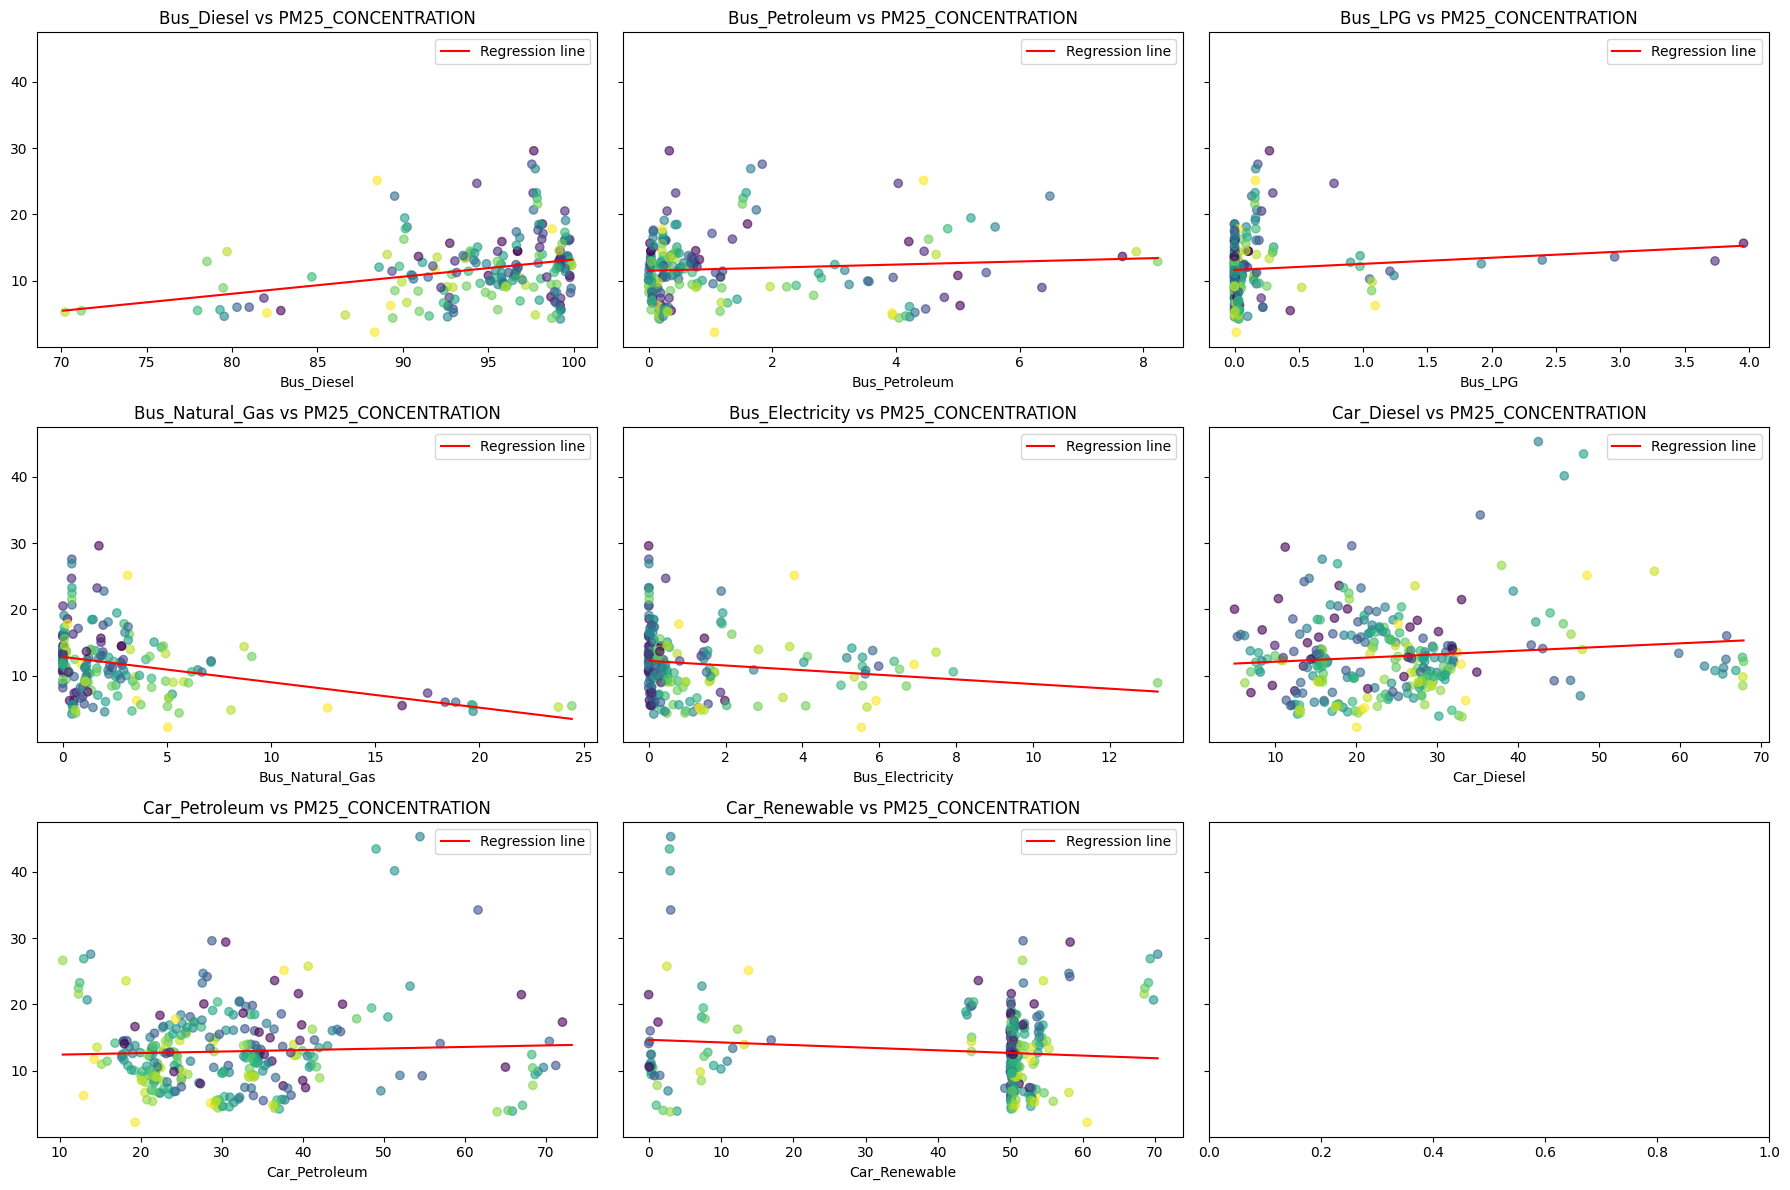

Plotting pm10_concentration


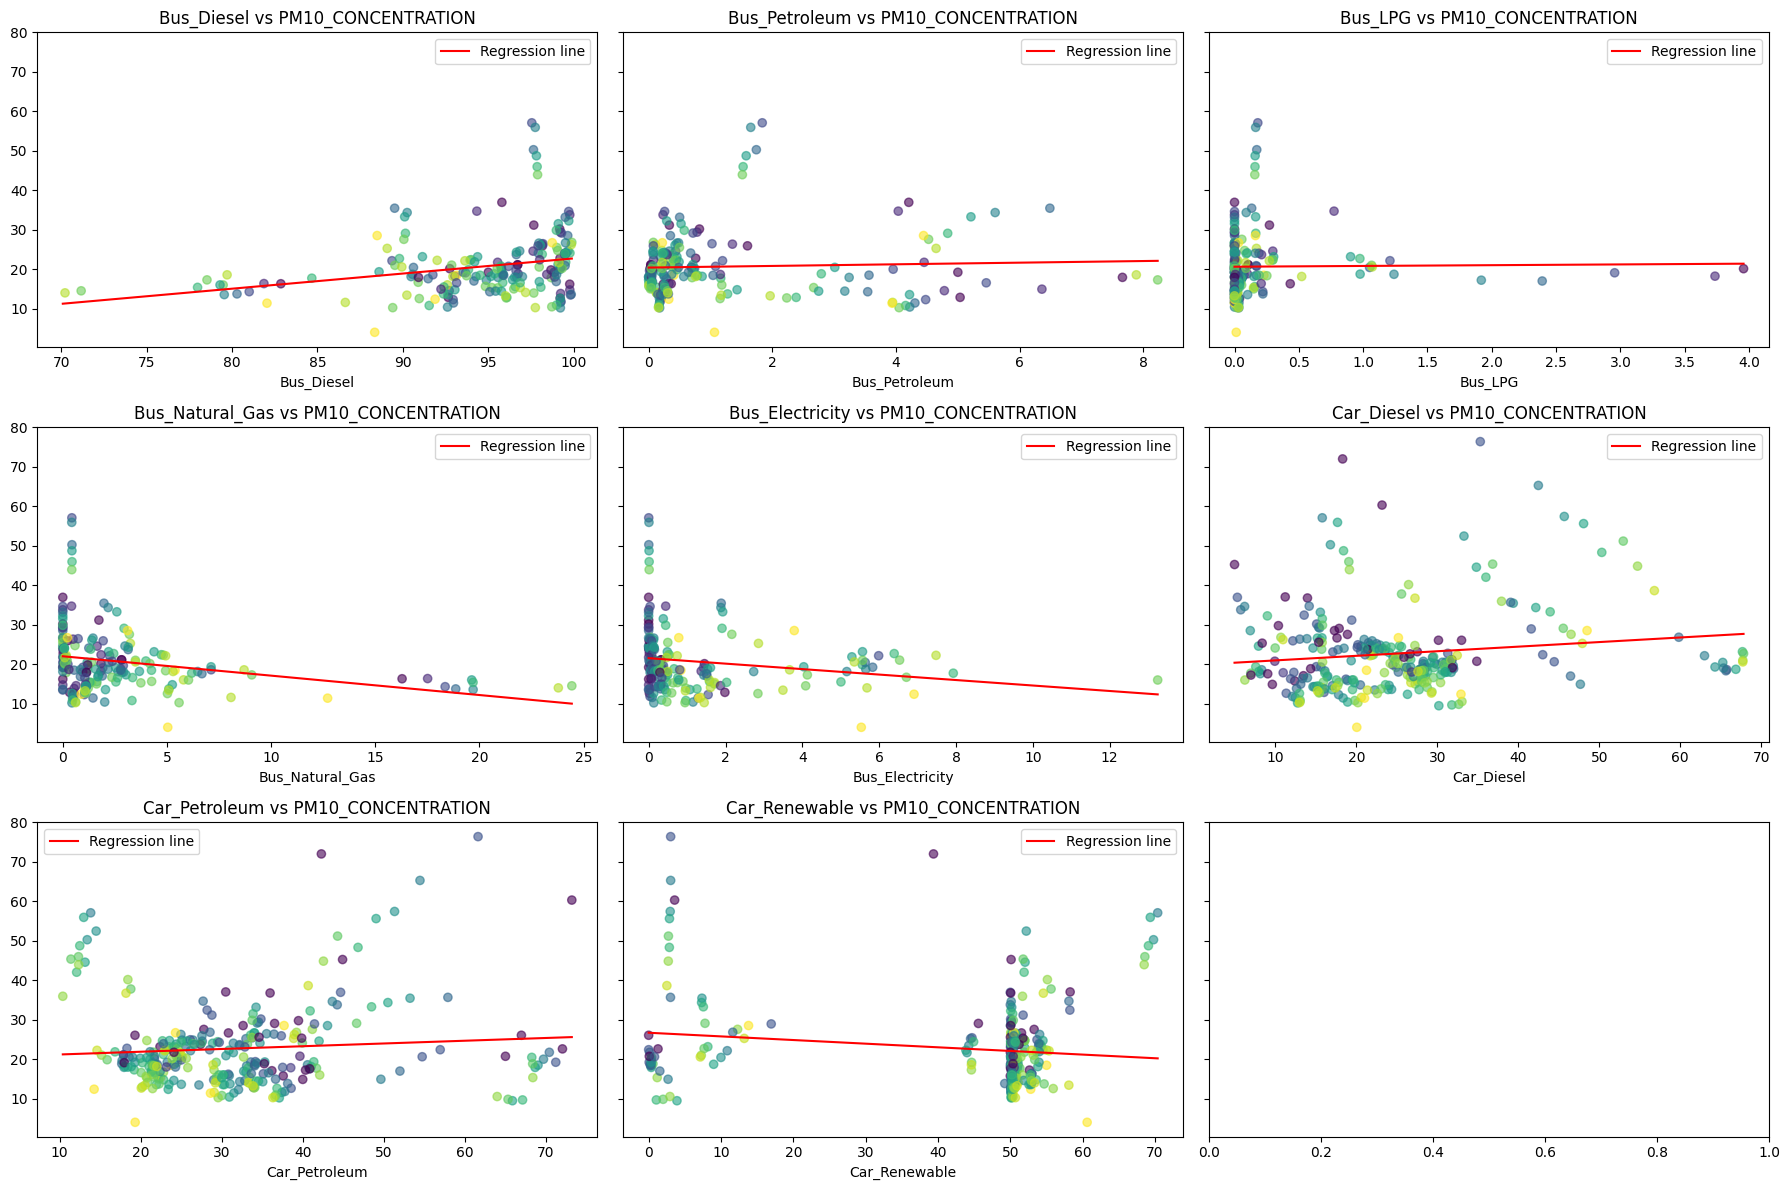

Plotting no2_concentration


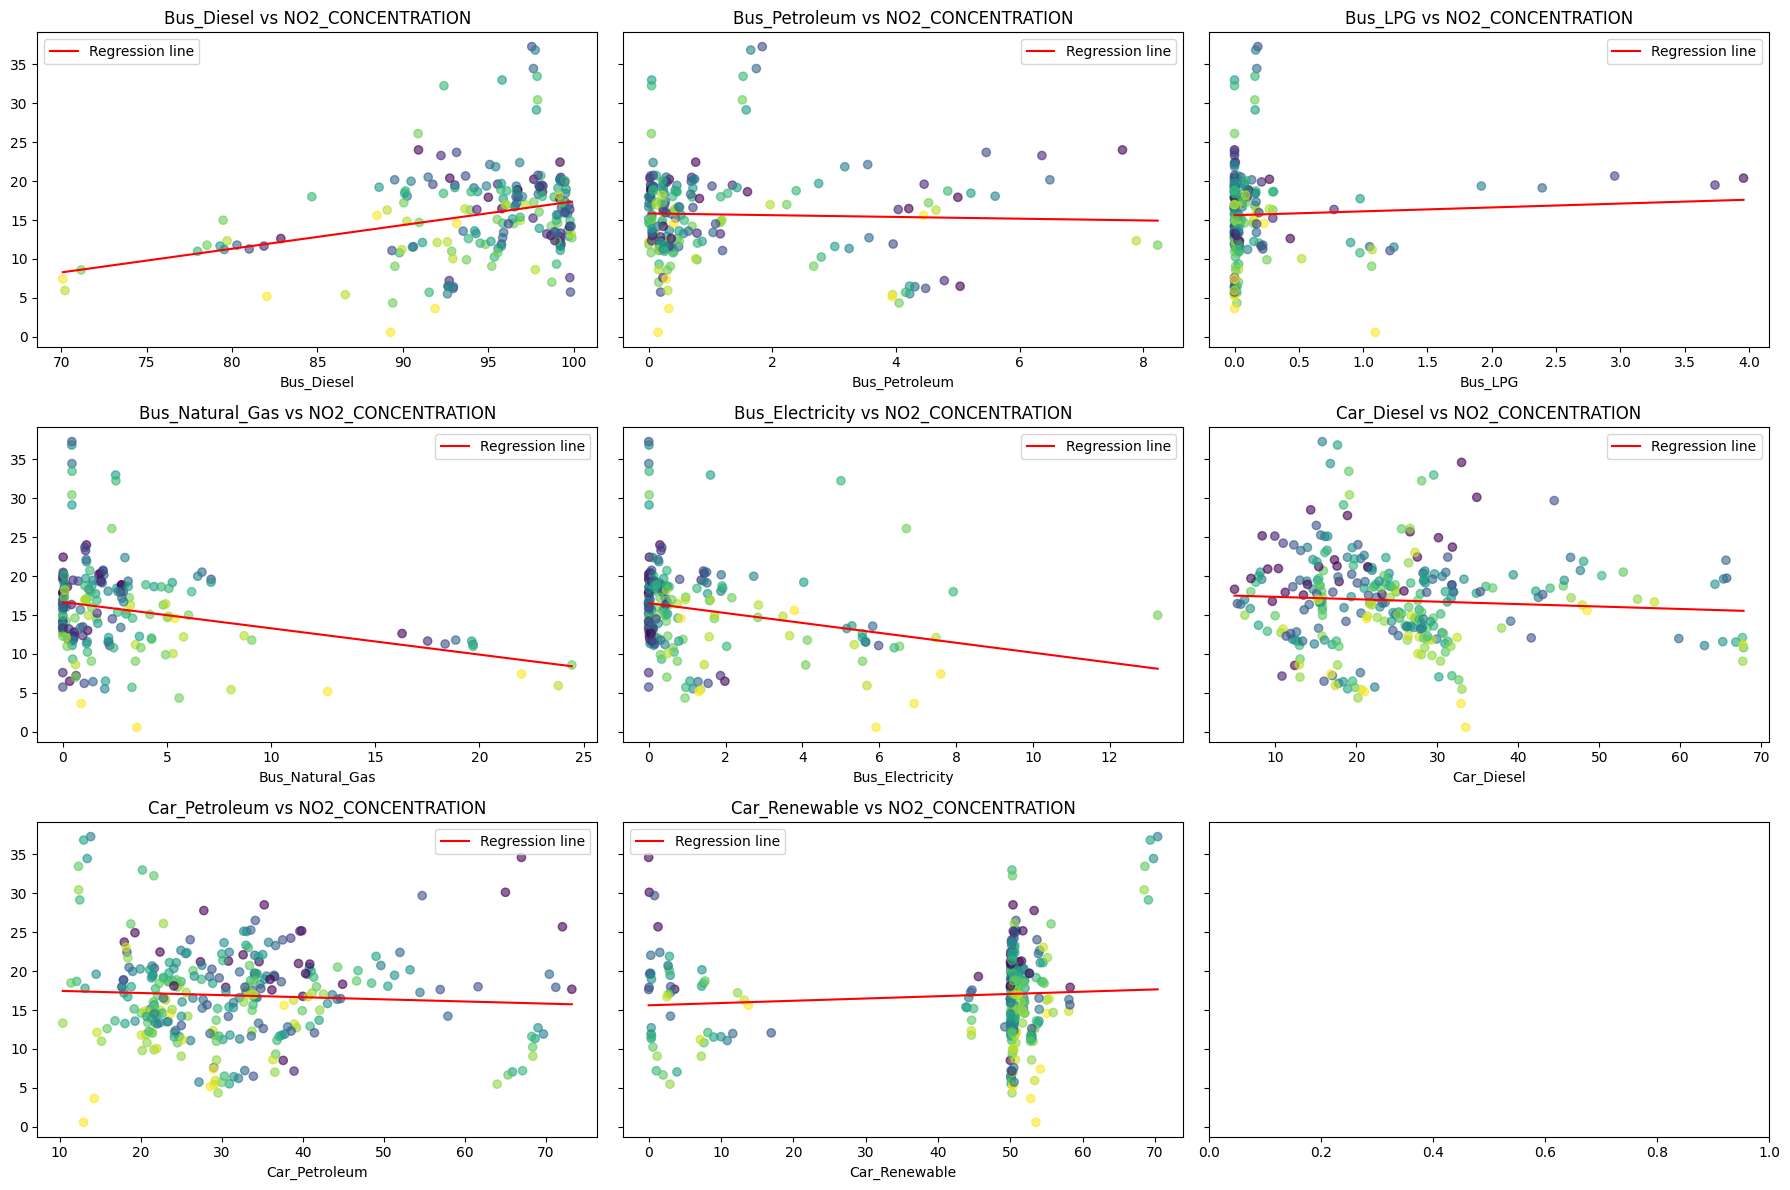

In [22]:
motor_transport = ['Bus_Diesel', 'Bus_Petroleum', 'Bus_LPG', 'Bus_Natural_Gas', 'Bus_Electricity','Car_Diesel', 'Car_Petroleum', 'Car_Renewable']

correlation_results_propultion['pm25']=plot_pollutant_vs_x(df_all_clean_calc, "pm25_concentration", motor_transport)
correlation_results_propultion['pm10']=plot_pollutant_vs_x(df_all_clean_calc, "pm10_concentration", motor_transport)
correlation_results_propultion['no2']=plot_pollutant_vs_x(df_all_clean_calc, "no2_concentration", motor_transport)

### Transport Age Type ###

Plotting pm25_concentration


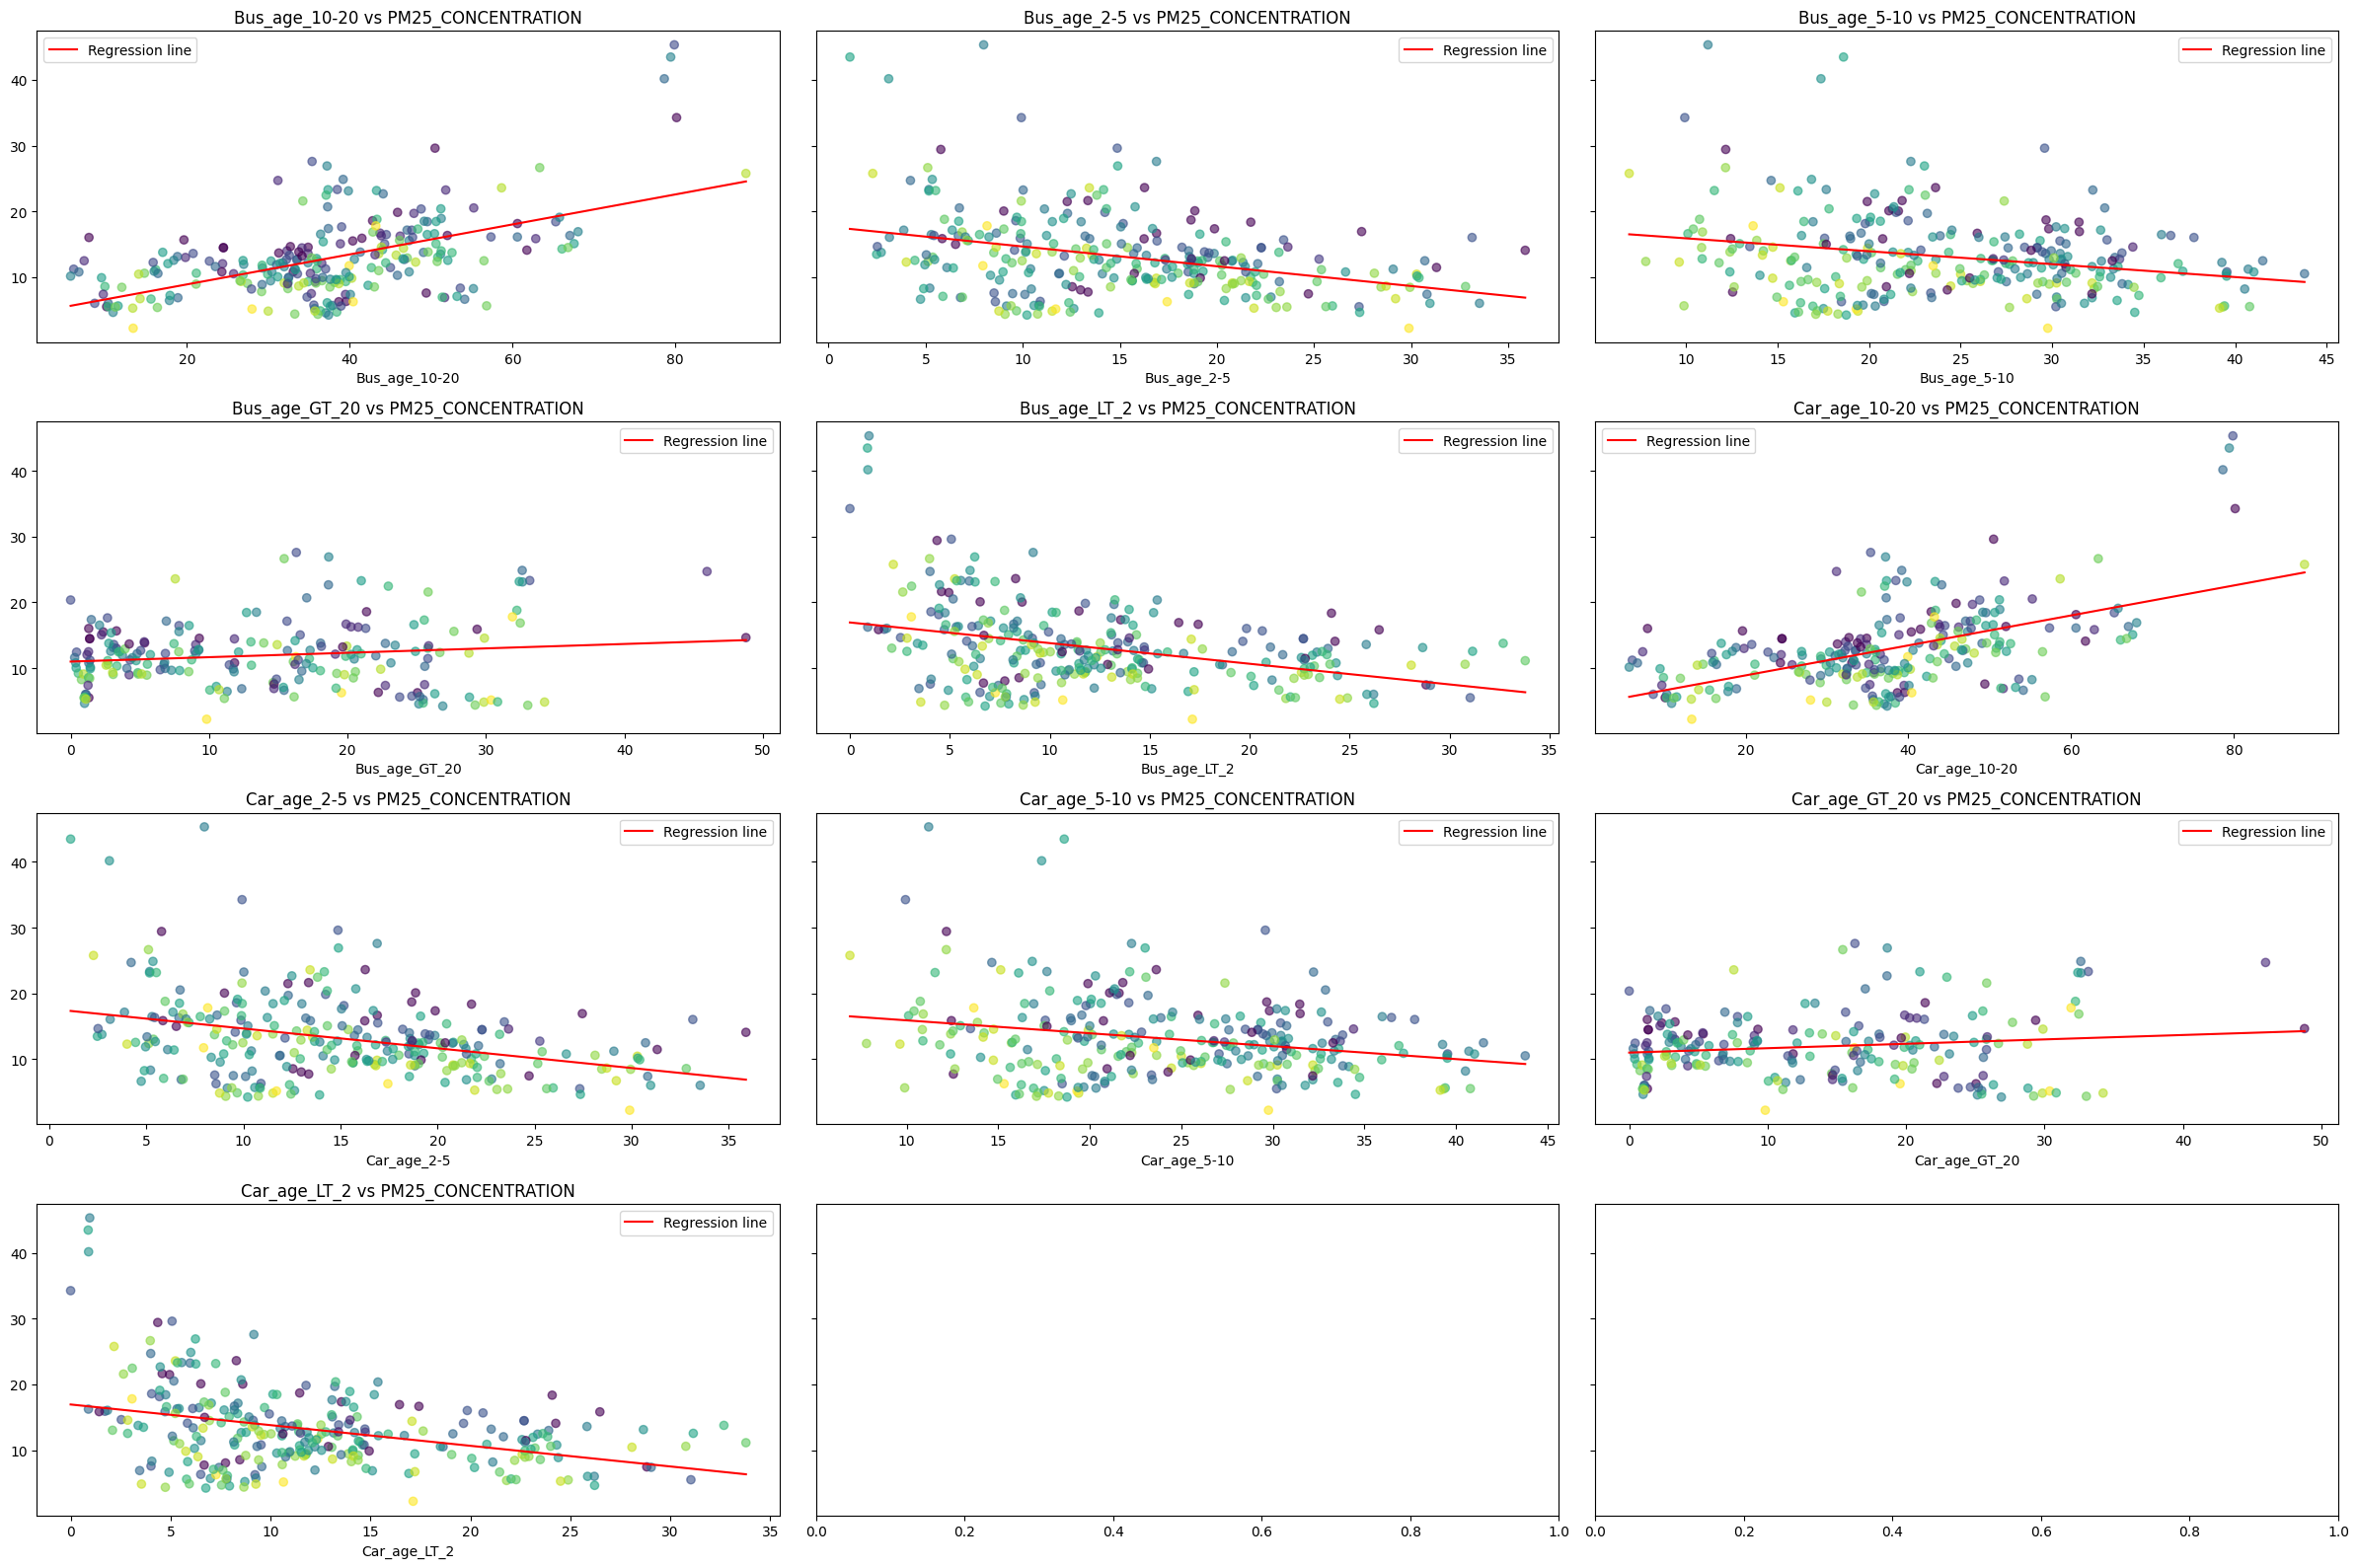

Plotting pm10_concentration


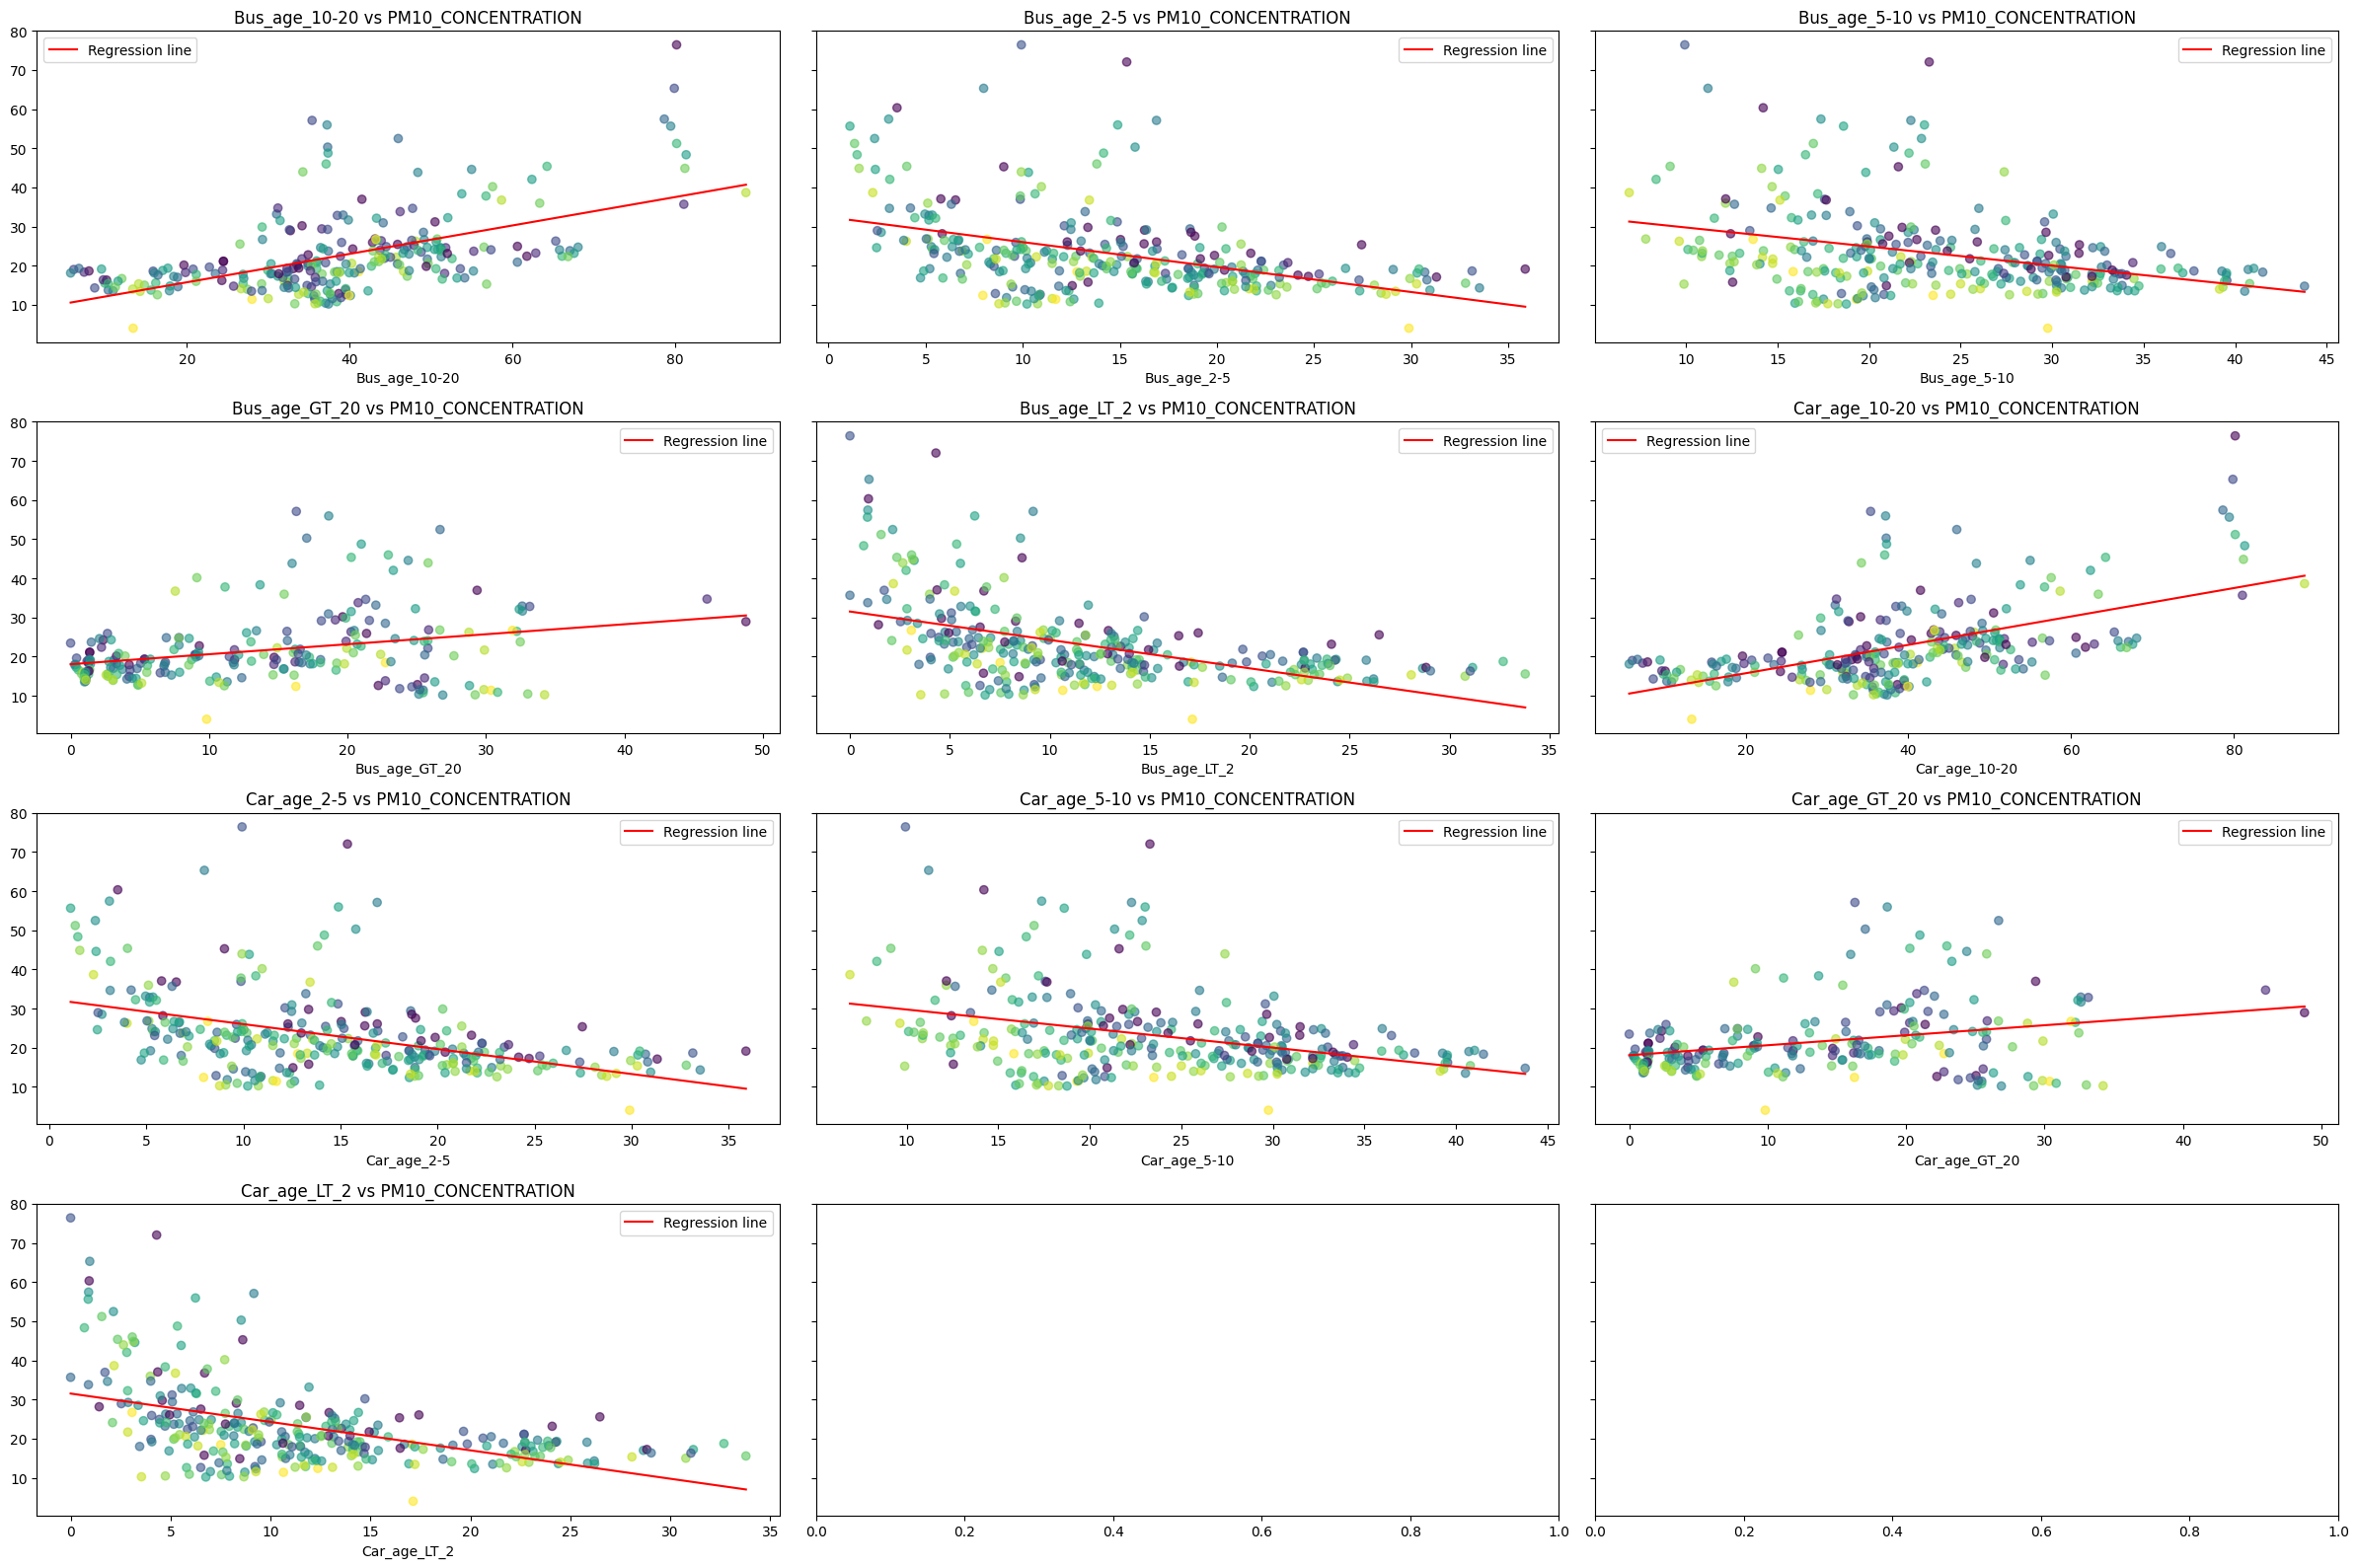

Plotting no2_concentration


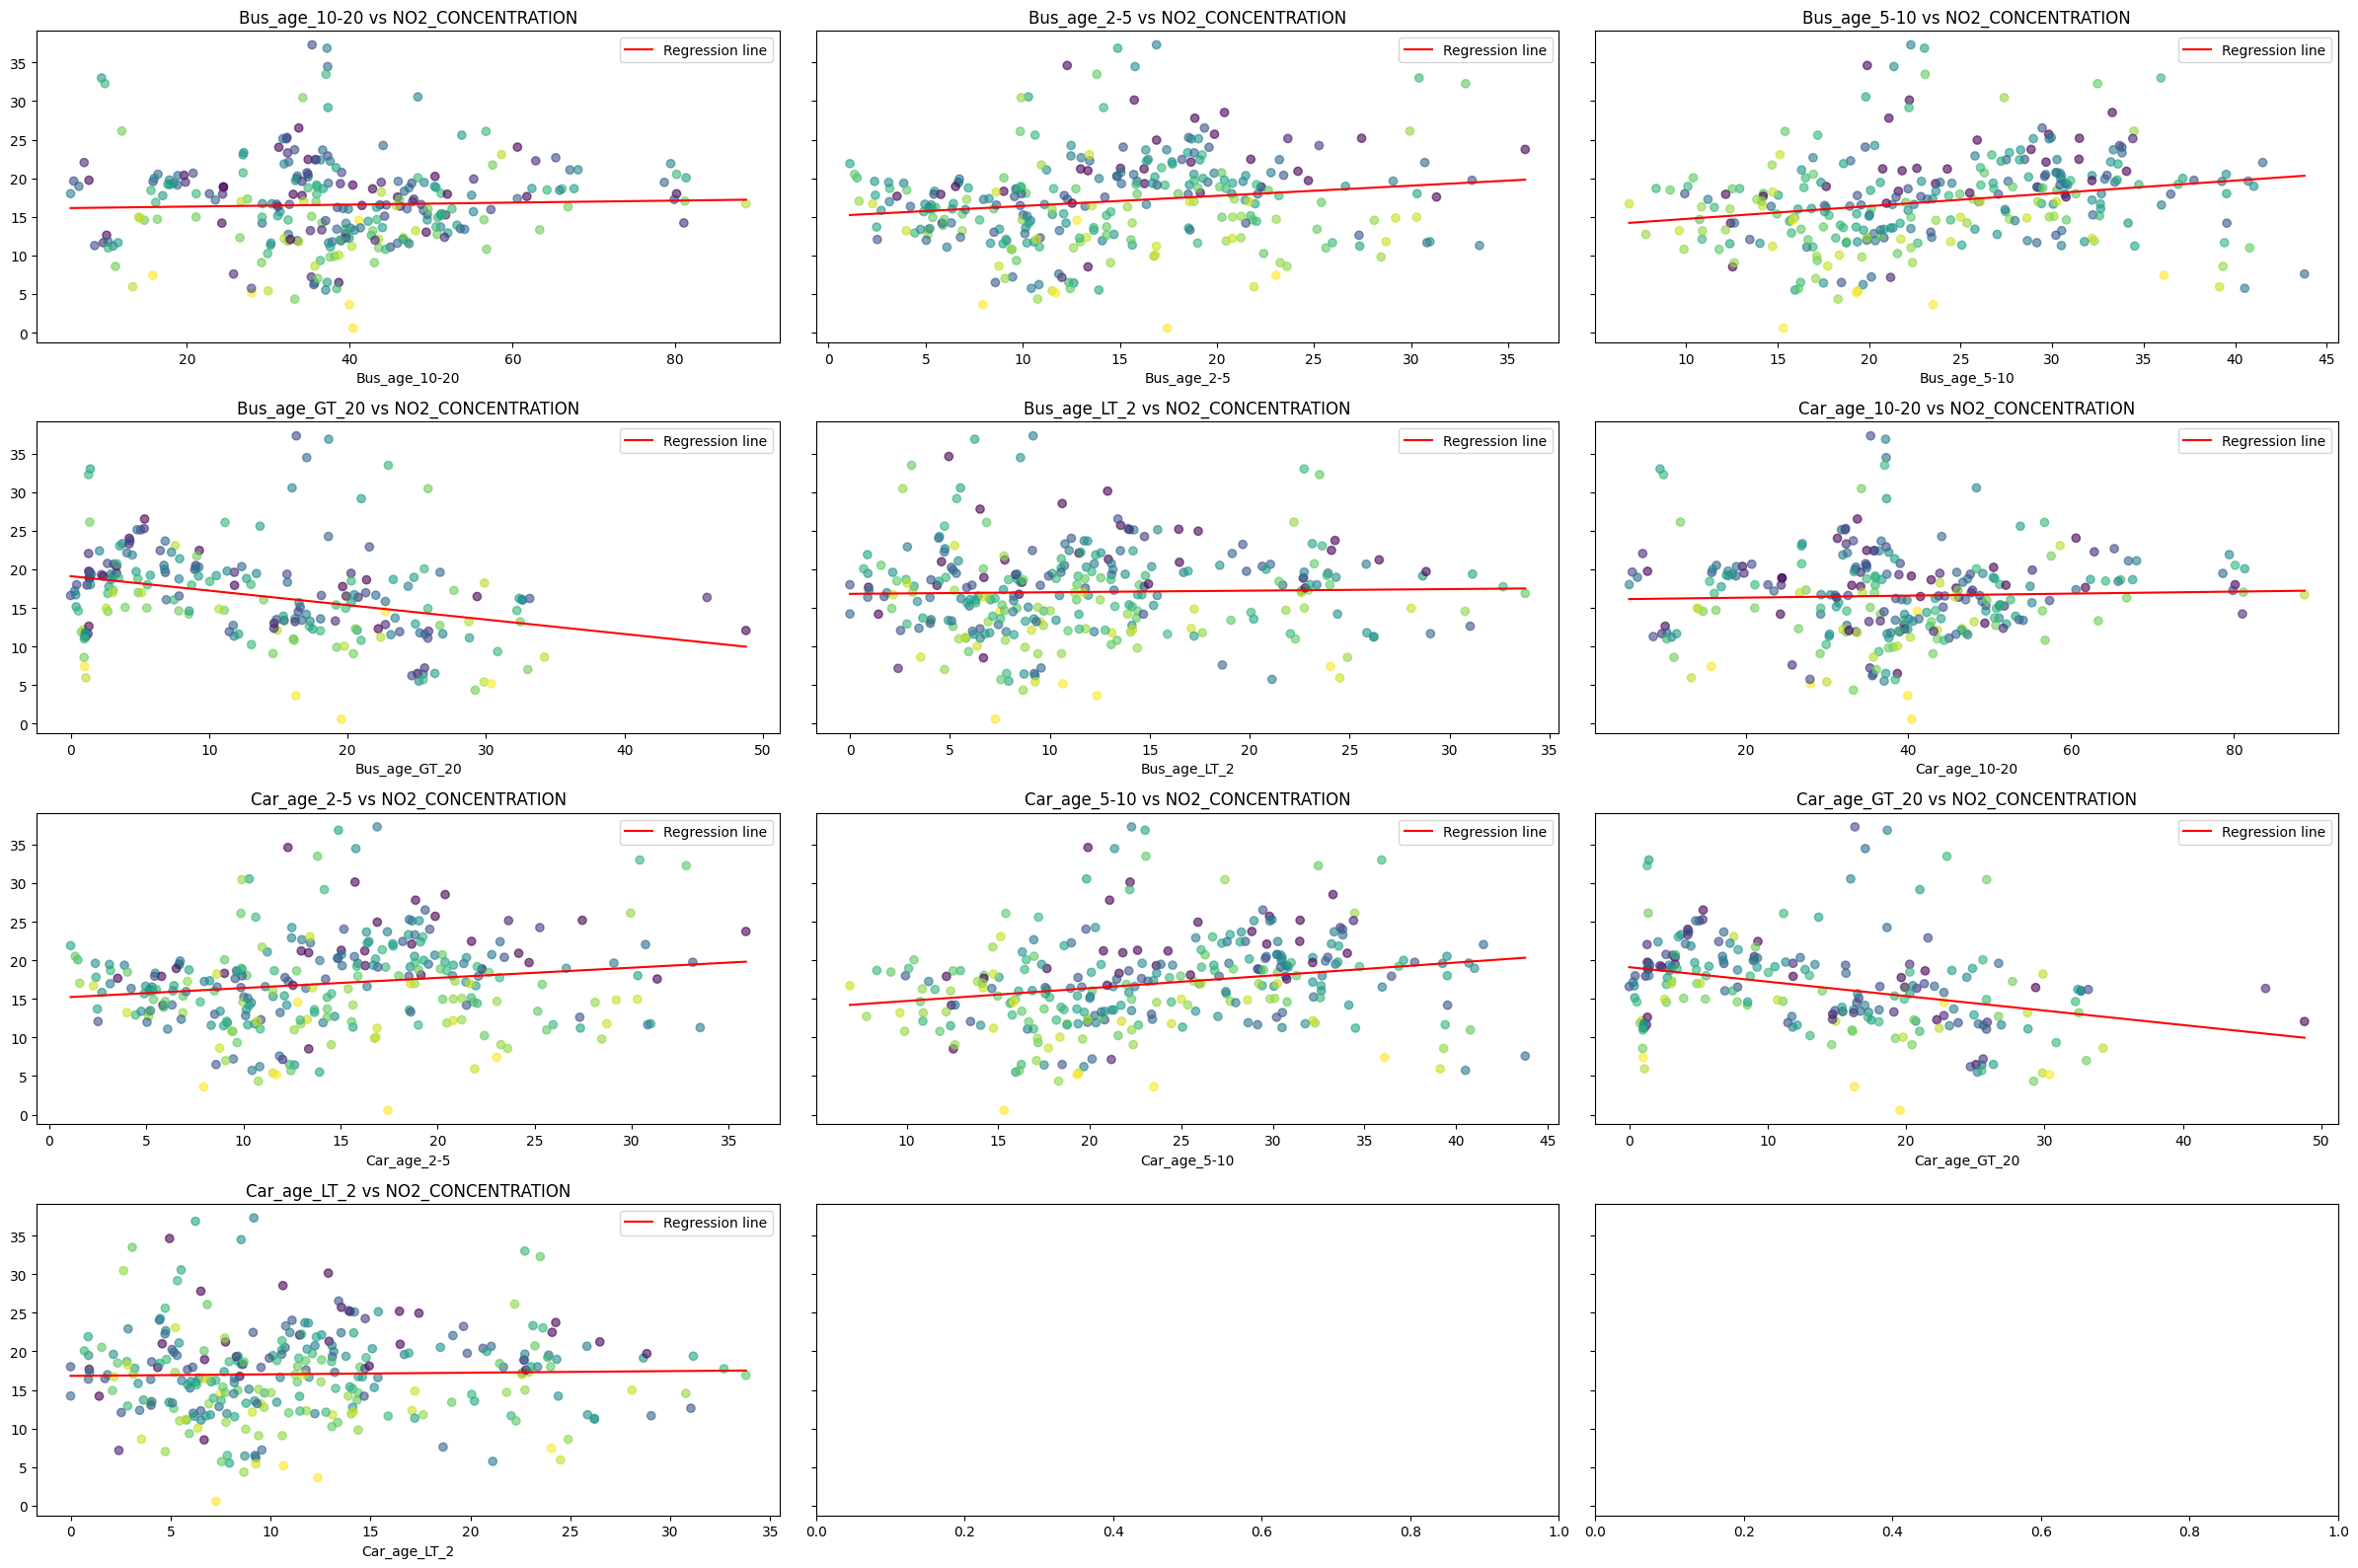

In [23]:
Age_transport = ['Bus_age_10-20', 'Bus_age_2-5', 'Bus_age_5-10', 'Bus_age_GT_20', 'Bus_age_LT_2', 'Car_age_10-20', 'Car_age_2-5', 'Car_age_5-10','Car_age_GT_20', 'Car_age_LT_2']

correlation_results_type_age['pm25'] = plot_pollutant_vs_x(df_all_clean_calc, "pm25_concentration", Age_transport)
correlation_results_type_age['pm10'] = plot_pollutant_vs_x(df_all_clean_calc, "pm10_concentration", Age_transport)
correlation_results_type_age['no2'] = plot_pollutant_vs_x(df_all_clean_calc, "no2_concentration", Age_transport)

### Modal share ###

Plotting pm25_concentration


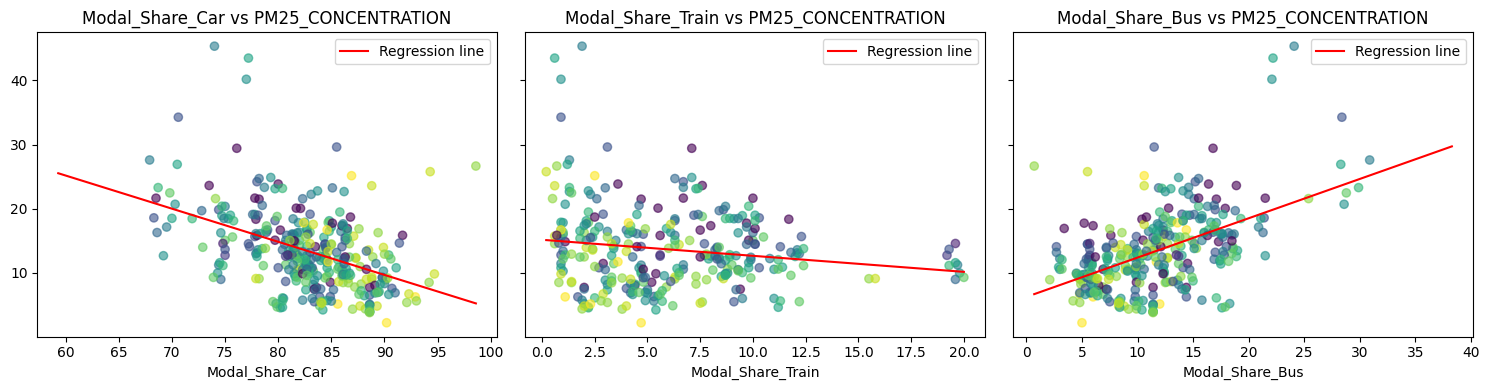

Plotting pm10_concentration


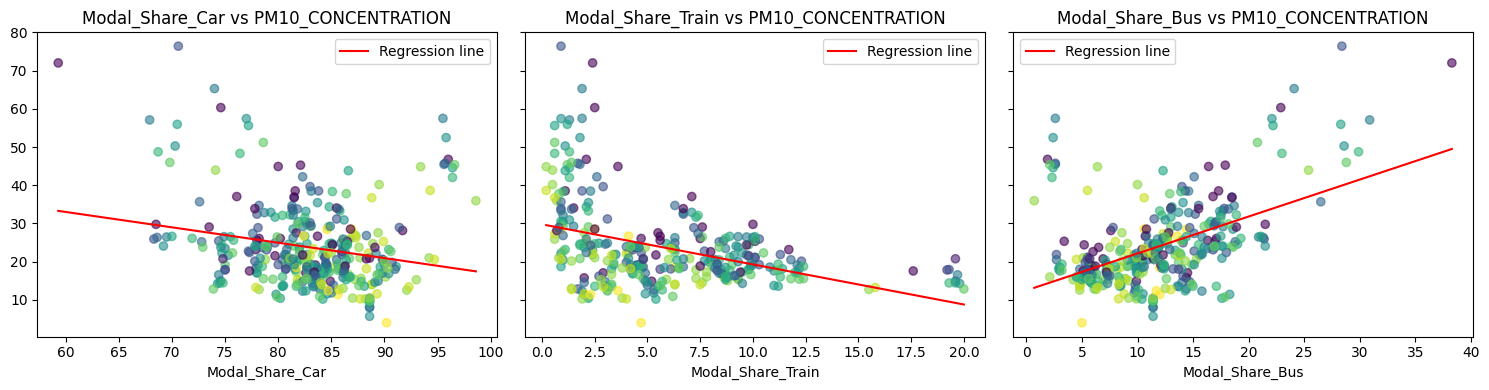

Plotting no2_concentration


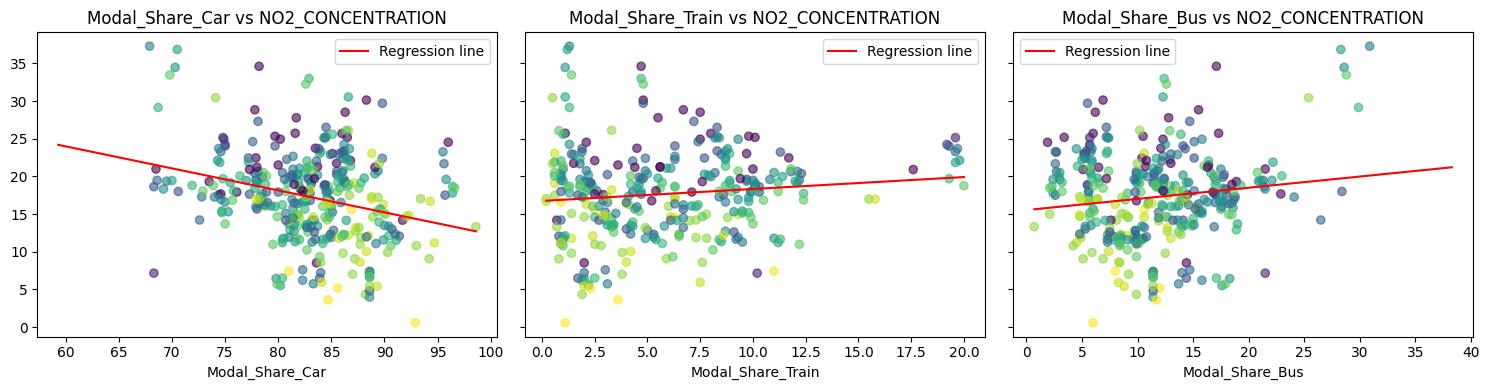

In [24]:
Modal_share_transport = ['Modal_Share_Car', 'Modal_Share_Train', 'Modal_Share_Bus']

correlation_results_modal_share['pm25'] = plot_pollutant_vs_x(df_all_clean_calc, "pm25_concentration", Modal_share_transport)
correlation_results_modal_share['pm10'] = plot_pollutant_vs_x(df_all_clean_calc, "pm10_concentration", Modal_share_transport)
correlation_results_modal_share['no2'] = plot_pollutant_vs_x(df_all_clean_calc, "no2_concentration", Modal_share_transport)

### Total Transport ###

Plotting pm25_concentration


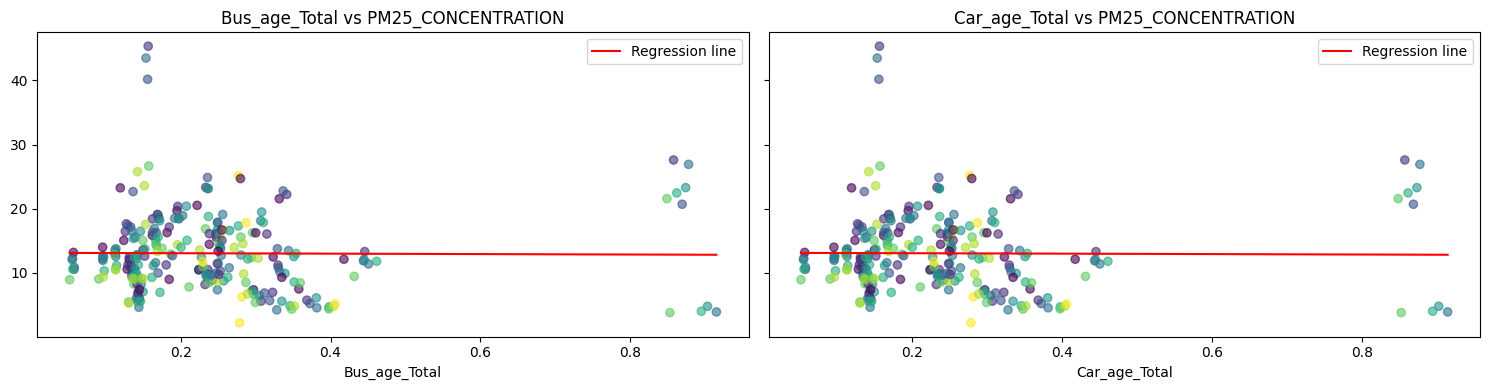

Plotting pm10_concentration


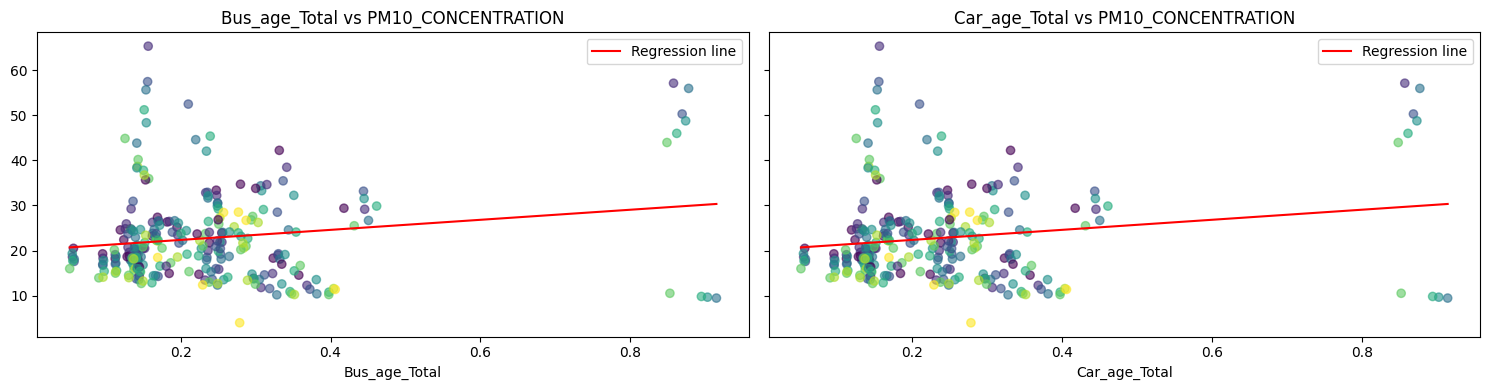

Plotting no2_concentration


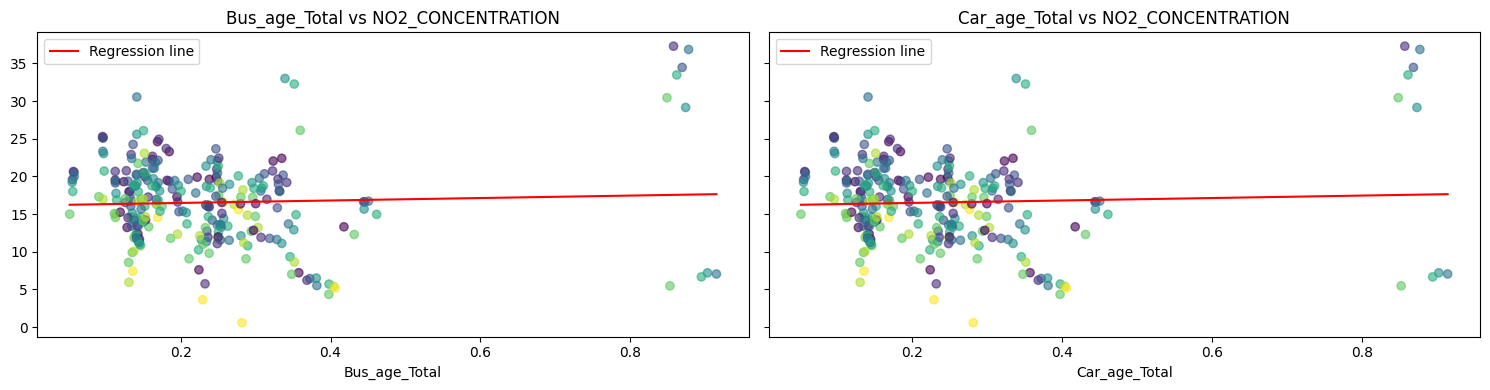

In [25]:
Total_transport = ['Bus_age_Total', 'Car_age_Total']

correlation_results_Total_transport['pm25'] = plot_pollutant_vs_x(df_all_clean_calc, "pm25_concentration", Total_transport)
correlation_results_Total_transport['pm10'] = plot_pollutant_vs_x(df_all_clean_calc, "pm10_concentration", Total_transport)
correlation_results_Total_transport['no2'] = plot_pollutant_vs_x(df_all_clean_calc, "no2_concentration", Total_transport)

### Population Age ###

Plotting pm25_concentration


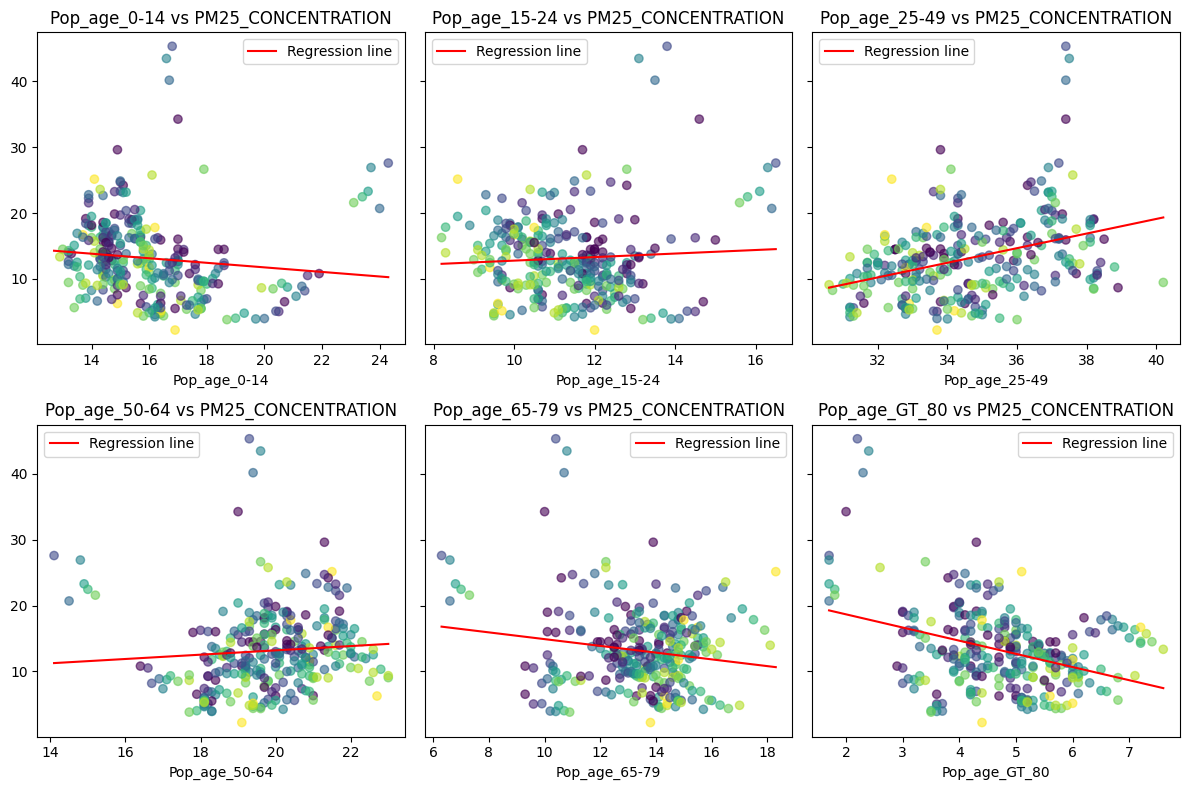

Plotting pm10_concentration


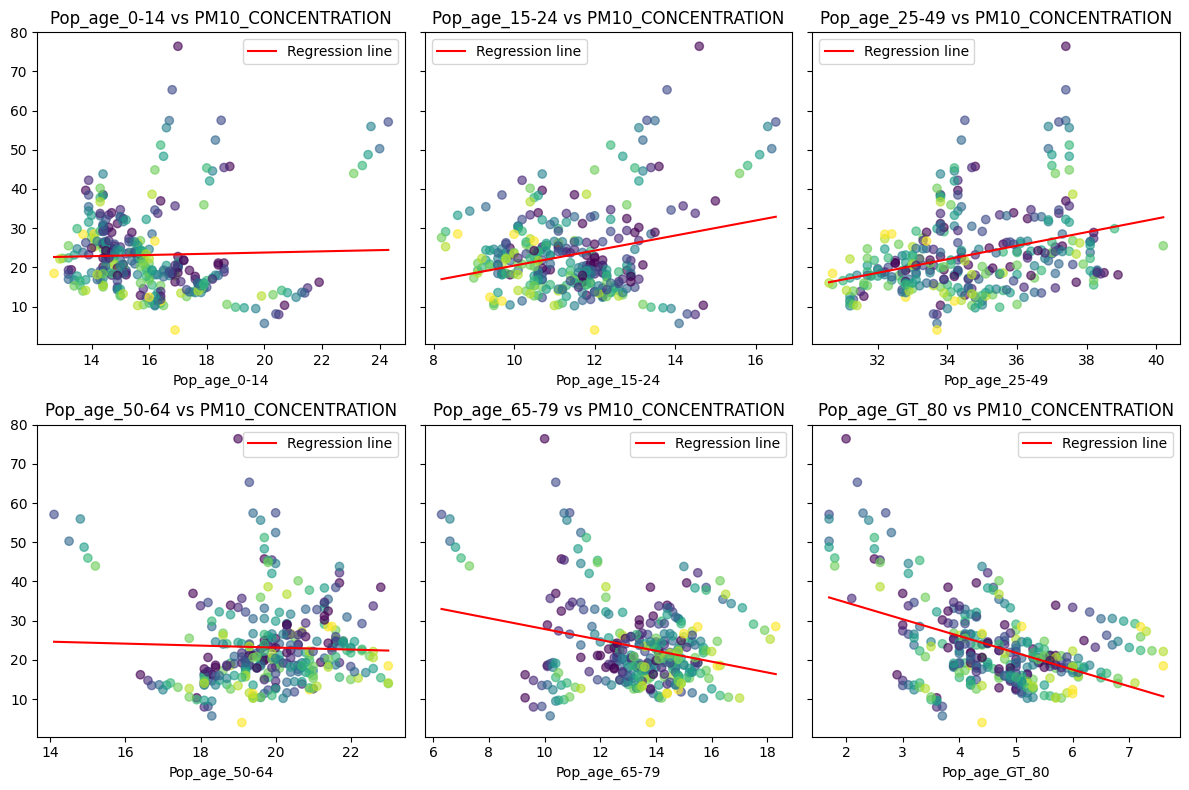

Plotting no2_concentration


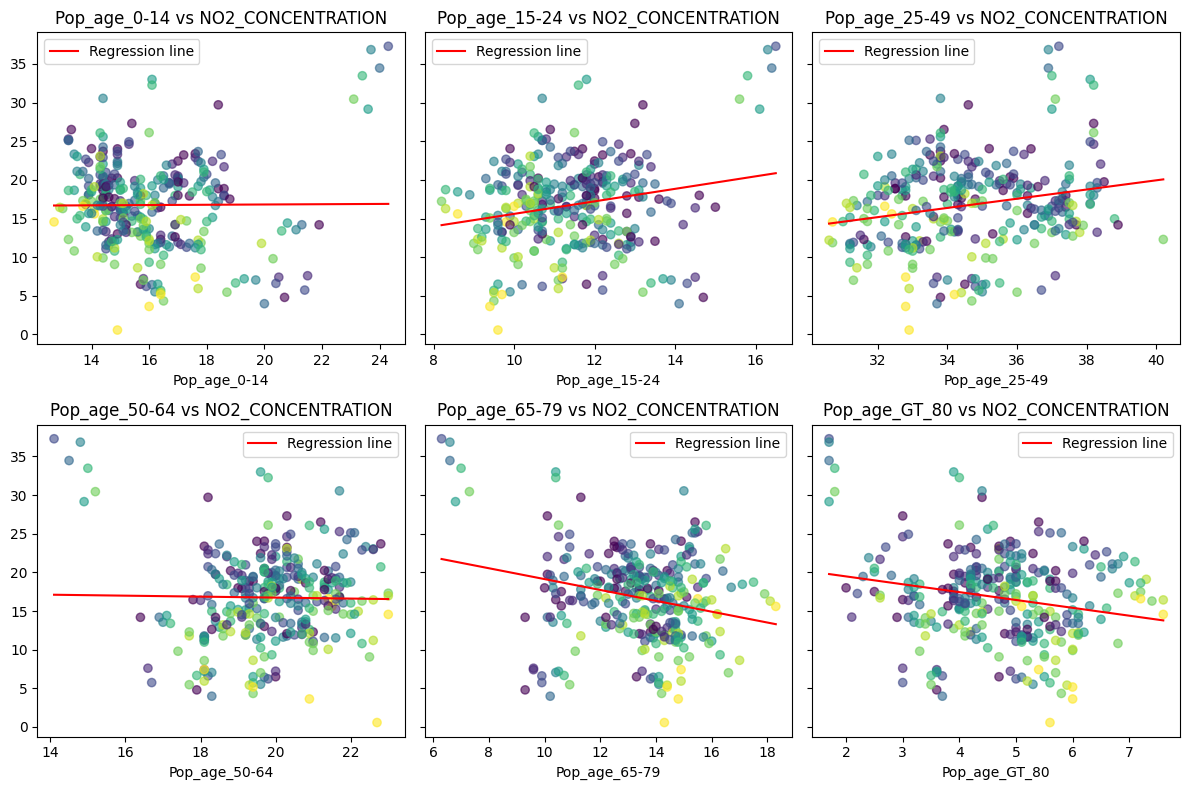

In [26]:
pop_age = ['Pop_age_0-14', 'Pop_age_15-24', 'Pop_age_25-49',
       'Pop_age_50-64', 'Pop_age_65-79', 'Pop_age_GT_80']

correlation_results_POP_Age['pm25'] = plot_pollutant_vs_x(df_all_clean_calc, "pm25_concentration", pop_age)
correlation_results_POP_Age['pm10'] = plot_pollutant_vs_x(df_all_clean_calc, "pm10_concentration", pop_age)
correlation_results_POP_Age['no2'] = plot_pollutant_vs_x(df_all_clean_calc, "no2_concentration", pop_age)

### GDP per capita, Population & Population Density ###

Plotting pm25_concentration


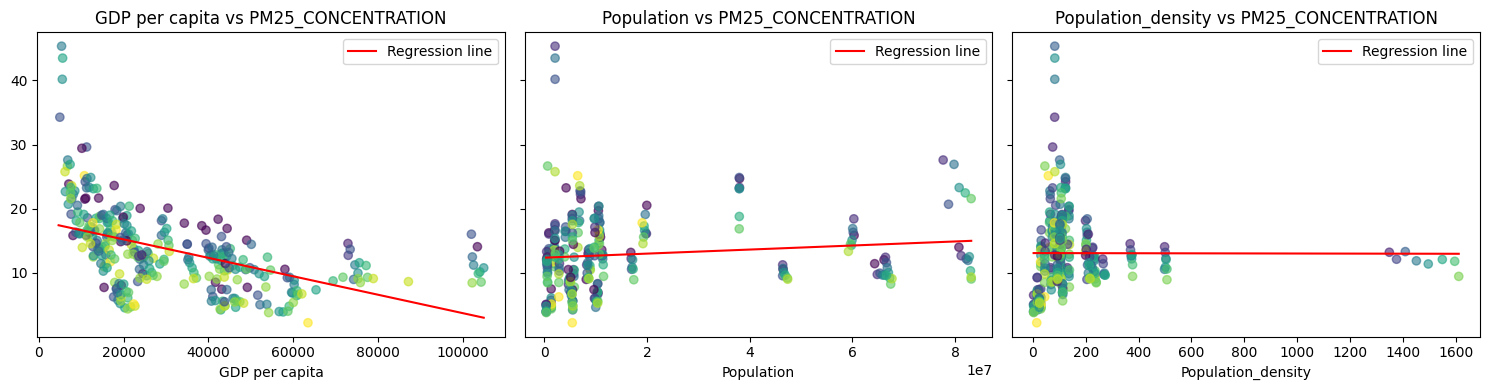

Plotting pm10_concentration


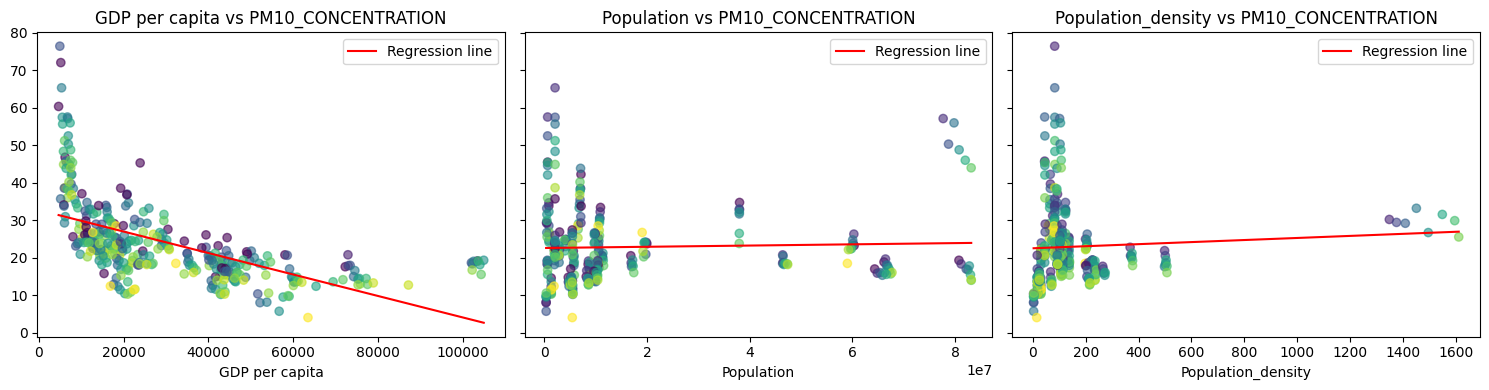

Plotting no2_concentration


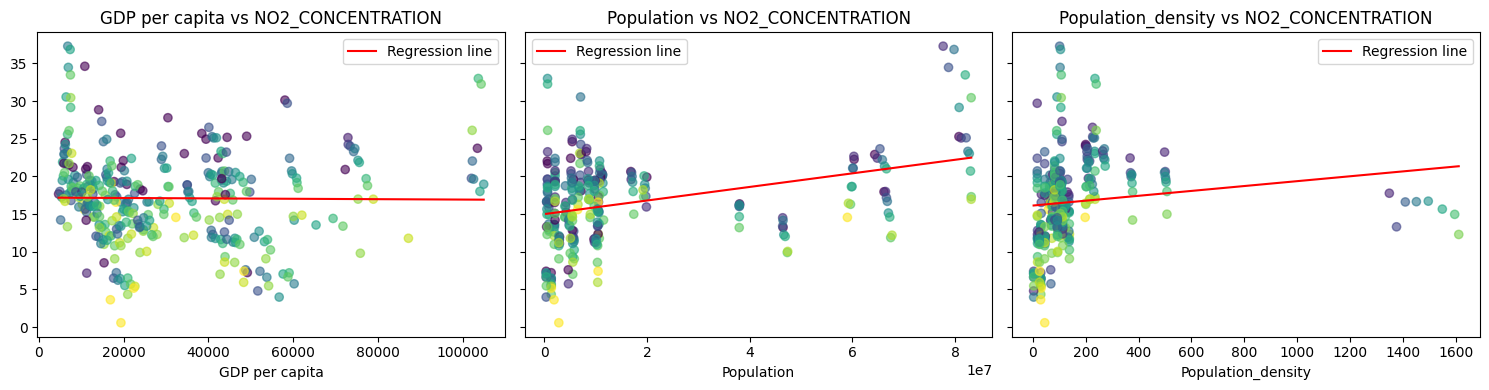

In [27]:
statistics = ['GDP per capita', 'Population', 'Population_density']

correlation_results_GDP['pm25'] = plot_pollutant_vs_x(df_all_clean_calc, "pm25_concentration", statistics)
correlation_results_GDP['pm10'] = plot_pollutant_vs_x(df_all_clean_calc, "pm10_concentration", statistics)
correlation_results_GDP['no2'] = plot_pollutant_vs_x(df_all_clean_calc, "no2_concentration", statistics)

## Correlation ##

In [28]:
correlation_df = pd.concat([
    pd.DataFrame(correlation_results_propultion),
    pd.DataFrame(correlation_results_modal_share),
    pd.DataFrame(correlation_results_Total_transport),
    pd.DataFrame(correlation_results_POP_Age),
    pd.DataFrame(correlation_results_GDP)
])

correlation_df

,pm25,pm10,no2
Bus_Diesel,0.290848,0.264365,0.300511
Bus_Petroleum,0.083875,0.045875,-0.034071
Bus_LPG,0.100999,0.012863,0.045795
Bus_Natural_Gas,-0.342950,-0.269872,-0.265951
Bus_Electricity,-0.147202,-0.176456,-0.227490
Car_Diesel,0.112868,0.139095,-0.067652
Car_Petroleum,0.046703,0.083871,-0.059389
Car_Renewable,-0.113397,-0.157084,0.089765
Modal_Share_Car,-0.441581,-0.211894,-0.277716
Modal_Share_Train,-0.166237,-0.407547,0.115014


<Axes: title={'center': 'Correlation between Transport Factors and Air Pollutants'}, ylabel='Correlation Coefficient'>

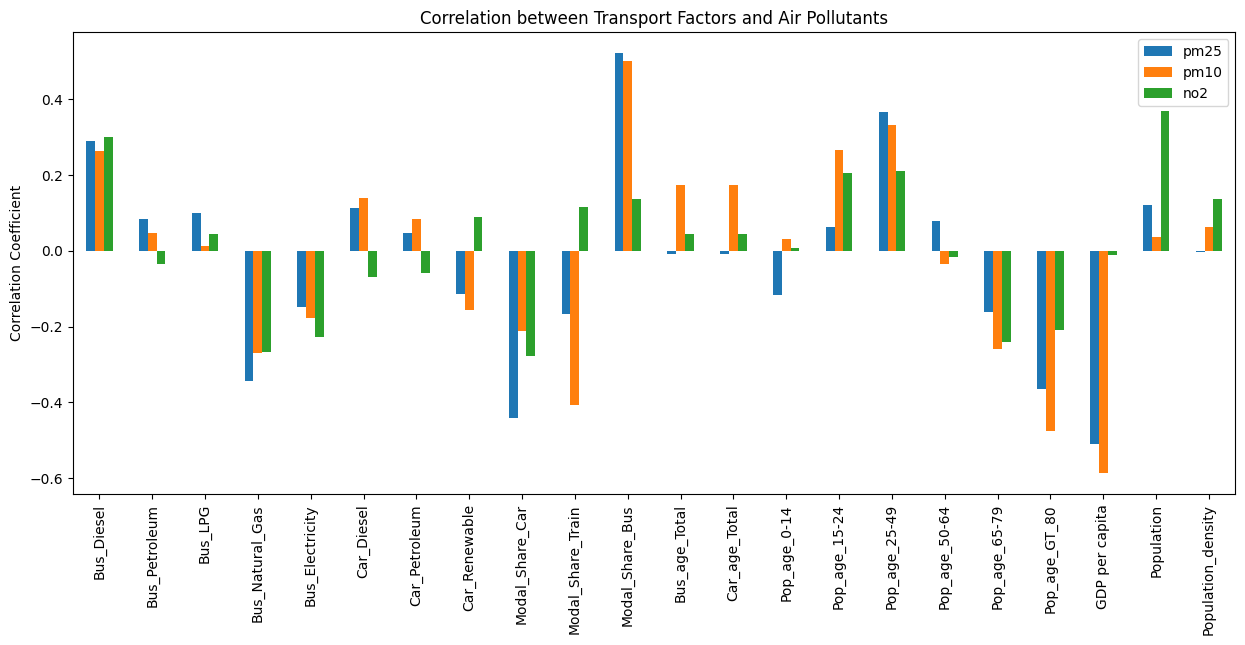

In [29]:
correlation_df.plot(kind='bar', figsize=(15, 6), ylabel='Correlation Coefficient', title='Correlation between Transport Factors and Air Pollutants')

## Modeling ##

In [ ]:
df_all_clean_calc.to_csv("data/EU_Data_clean.csv", index=False)

### Load Data ### 

In [2]:
df_total = pd.read_csv("data/EU_Data_clean.csv")
df_total

,Country,Year,Bus_age_Total,Bus_age_10-20,Bus_age_2-5,Bus_age_5-10,Bus_age_GT_20,Bus_age_LT_2,Bus_Diesel,Bus_Petroleum,...,Pop_age_50-64,Pop_age_65-79,Pop_age_GT_80,Modal_Share_Bus,Modal_Share_Car,Modal_Share_Train,pm10_concentration,pm25_concentration,no2_concentration,Bus_motor_Total
0,Austria,2010.0,NaN,NaN,21.745439,31.467662,NaN,24.087894,NaN,NaN,...,NaN,NaN,NaN,10.4,77.9,11.7,23.169136,18.357364,22.458091,NaN
1,Austria,2013.0,NaN,19.626266,23.436684,32.999269,3.309322,20.628458,92.743788,0.020881,...,19.7,13.1,5.0,9.9,77.8,12.3,20.139984,15.660818,20.383615,9578.0
2,Austria,2014.0,0.112662,19.812207,19.530516,33.427230,3.317684,23.912363,93.041210,0.031299,...,20.0,13.3,5.0,9.9,77.9,12.2,18.240947,12.987581,19.499727,9585.0
3,Austria,2015.0,0.112744,20.756276,19.857423,30.437029,3.120157,25.829115,93.666701,0.030995,...,20.3,13.4,5.0,9.9,78.1,12.1,19.097495,13.590971,20.660936,9679.0
4,Austria,2016.0,0.112925,18.829517,18.585242,30.849873,3.083969,28.651399,94.157761,0.040712,...,20.6,13.5,4.9,9.9,78.0,12.1,17.014330,13.122824,19.133991,9825.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,United Kingdom,2015.0,0.250867,35.838005,16.456459,30.267493,6.470964,10.967080,NaN,NaN,...,18.4,13.0,4.8,5.2,86.1,8.7,15.864308,9.752607,22.425663,NaN
344,United Kingdom,2016.0,0.247021,36.663777,16.337461,28.278019,6.830960,11.889783,NaN,NaN,...,18.5,13.1,4.8,4.5,86.7,8.8,15.998788,9.949446,23.661133,NaN
345,United Kingdom,2017.0,0.240617,37.590891,16.374849,27.205994,7.282620,11.545647,NaN,NaN,...,18.7,13.2,4.9,5.0,86.4,8.7,15.300830,9.666053,22.206474,NaN
346,United Kingdom,2018.0,0.233864,38.321182,17.151429,26.081683,7.871476,10.574231,NaN,NaN,...,18.9,13.3,4.9,4.6,86.8,8.7,16.015115,9.631000,21.365400,NaN


In [3]:
df_shift = df_total.copy()
df_shift = df_shift.sort_values(by=['Country', 'Year'])
df_shift.drop(columns=['Country','Year'], inplace=True)

In [4]:
# Create multiple shifted versions (e.g., lag 1, 2, 3)
shifted_dfs = []

for lag in range(1, 51, 5):
    shifted = df_shift - df_shift.shift(lag)
    shifted['lag'] = lag  # Add a column to indicate the lag
    shifted_dfs.append(shifted)

# Concatenate all shifted dataframes as rows
df_multi_shift = pd.concat(shifted_dfs, axis=0, ignore_index=True)

# Drop rows where all values are NaN (except 'lag')
df_multi_shift = df_multi_shift.dropna(how='all', subset=[col for col in df_shift.columns])

df_multi_shift

,Bus_age_Total,Bus_age_10-20,Bus_age_2-5,Bus_age_5-10,Bus_age_GT_20,Bus_age_LT_2,Bus_Diesel,Bus_Petroleum,Bus_LPG,Bus_Natural_Gas,...,Pop_age_65-79,Pop_age_GT_80,Modal_Share_Bus,Modal_Share_Car,Modal_Share_Train,pm10_concentration,pm25_concentration,no2_concentration,Bus_motor_Total,lag
1,NaN,NaN,1.691245,1.531608,NaN,-3.459436,NaN,NaN,NaN,NaN,...,NaN,NaN,-0.5,-0.1,0.6,-3.029152,-2.696545,-2.074476,NaN,1
2,NaN,0.185941,-3.906168,0.427961,0.008361,3.283905,0.297422,0.010418,-0.221982,-0.001334,...,0.2,0.0,0.0,0.1,-0.1,-1.899036,-2.673238,-0.883888,7.0,1
3,0.000083,0.944070,0.326907,-2.990201,-0.197527,1.916752,0.625491,-0.000304,-0.780152,0.095917,...,0.1,0.0,0.0,0.2,-0.1,0.856547,0.603390,1.161209,94.0,1
4,0.000181,-1.926760,-1.272182,0.412844,-0.036188,2.822285,0.491060,0.009718,-0.562993,-0.028556,...,0.1,-0.1,0.0,-0.1,0.0,-2.083165,-0.468147,-1.526945,146.0,1
5,0.000561,-0.458685,2.226329,-4.072050,-0.191241,2.495648,0.729744,-0.000536,-0.473416,-0.175573,...,0.1,0.0,0.1,0.0,-0.1,0.211535,-0.569176,0.235200,131.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3475,0.139266,0.523768,-4.791938,0.169160,2.537659,1.561351,NaN,NaN,NaN,NaN,...,-1.8,-0.6,-3.4,-3.9,7.3,-4.303692,-3.162593,7.357263,NaN,46
3476,NaN,NaN,-2.810589,2.780381,NaN,-3.046561,NaN,NaN,NaN,NaN,...,NaN,NaN,-7.8,4.4,3.4,-5.756476,0.083730,5.567176,NaN,46
3477,NaN,NaN,-2.317220,0.426751,NaN,-1.852794,NaN,NaN,NaN,NaN,...,NaN,NaN,-8.5,5.5,3.1,NaN,-3.124281,NaN,NaN,46
3478,NaN,NaN,-0.195182,-1.273268,NaN,-0.923893,NaN,NaN,NaN,NaN,...,NaN,NaN,-9.1,6.1,3.1,-2.007218,-2.967714,NaN,NaN,46


In [5]:
df_multi_shift.describe()

,Bus_age_Total,Bus_age_10-20,Bus_age_2-5,Bus_age_5-10,Bus_age_GT_20,Bus_age_LT_2,Bus_Diesel,Bus_Petroleum,Bus_LPG,Bus_Natural_Gas,...,Pop_age_65-79,Pop_age_GT_80,Modal_Share_Bus,Modal_Share_Car,Modal_Share_Train,pm10_concentration,pm25_concentration,no2_concentration,Bus_motor_Total,lag
count,1918.000000,1809.000000,2255.000000,2255.000000,1230.000000,2293.000000,988.000000,988.000000,988.000000,988.000000,...,2548.000000,2548.000000,3245.000000,3245.000000,2729.000000,3170.000000,2760.000000,3154.000000,988.000000,3245.000000
mean,0.009826,-0.872050,0.104027,0.240414,-1.002605,-0.360991,-0.032218,0.048046,-0.112207,0.088811,...,-0.097920,-0.028414,0.006379,-0.202866,0.277428,-0.009637,-0.306409,0.209509,29198.921053,22.864407
std,0.195316,21.819721,9.858294,10.439394,13.279038,9.568199,7.389483,2.310697,0.624696,5.528693,...,2.515569,1.566009,7.518518,7.552145,5.179868,14.292306,8.340726,7.898683,134511.368456,14.349546
min,-0.752481,-75.273278,-34.782329,-34.128208,-47.463778,-30.835430,-27.251586,-8.227383,-3.956985,-24.001627,...,-8.500000,-4.800000,-33.800000,-30.700000,-19.100000,-62.668724,-38.715105,-34.048000,-98395.000000,1.000000
25%,-0.076756,-13.451689,-5.409781,-6.217871,-10.437651,-5.756613,-3.188483,-0.367807,-0.044535,-1.600032,...,-1.400000,-1.000000,-4.600000,-4.500000,-2.900000,-7.289642,-5.010942,-4.610321,-5767.000000,11.000000
50%,0.001711,-0.870653,0.406021,-0.128706,0.128103,0.083031,-0.037494,-0.006139,0.000000,0.003745,...,0.200000,0.100000,-0.400000,0.000000,0.000000,-0.891334,-0.617106,-0.517970,544.500000,21.000000
75%,0.083986,9.403396,6.286951,6.906801,6.082144,5.406849,3.208679,0.603959,0.031291,1.831310,...,1.400000,1.000000,4.000000,4.200000,3.300000,7.065350,4.360166,5.077086,11268.000000,36.000000
max,0.818473,81.939904,30.632923,30.911299,40.201844,26.295708,27.652425,8.008467,1.239669,24.140448,...,6.900000,4.700000,32.600000,27.400000,18.800000,58.813515,36.898333,30.639500,700928.000000,46.000000


### PM10 ###

#### Prepare Data ####

In [6]:
def data_prep(df, target, cols_to_drop):
    """
    Prepare dataset for XGBoost regression.
    If 'Country' exists, it is one-hot encoded.
    Otherwise, only numeric features are used.
    """

    # Drop 'lag' if present
    if 'lag' in df.columns:
        df = df.drop(columns=['lag'], errors='ignore')

    # Drop 'Year' if present
    if "lag" in df.columns:
        df = df.drop(columns=['lag'], errors='ignore')


    # Drop 'Year' if present
    if "Year" in df.columns:
        df_res = df.drop(columns=["Year"], errors='ignore')
    else:
        df_res = df.copy()

    # Drop rows where target is missing
    df_res = df_res.dropna(subset=[target])
    df_res = df_res.drop(columns=cols_to_drop, errors='ignore')

    # Features and target
    X = df_res.drop(columns=[target])
    y = df_res[target]

    # Handle categorical encoding only if 'Country' exists
    if "Country" in X.columns:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        country_encoded = encoder.fit_transform(X[["Country"]])
        country_encoded_df = pd.DataFrame(
            country_encoded,
            columns=encoder.get_feature_names_out(["Country"]),
            index=X.index
        )

        # Combine numeric features with encoded country
        X_numeric = X.drop(columns=["Country"])
        X_encoded = pd.concat([X_numeric.reset_index(drop=True),
                               country_encoded_df.reset_index(drop=True)], axis=1)
    else:
        X_encoded = X.reset_index(drop=True)


    return X_encoded, y.reset_index(drop=True)

In [7]:
data_pm25 = data_prep(df_multi_shift, "pm25_concentration", ['pm10_concentration', 'no2_concentration'])
data_pm10 = data_prep(df_multi_shift, "pm10_concentration", ['pm25_concentration', 'no2_concentration'])
data_no2 = data_prep(df_multi_shift, "no2_concentration", ['pm25_concentration', 'pm10_concentration'])




In [11]:
data_pm25[0]

,Bus_age_Total,Bus_age_10-20,Bus_age_2-5,Bus_age_5-10,Bus_age_GT_20,Bus_age_LT_2,Bus_Diesel,Bus_Petroleum,Bus_LPG,Bus_Natural_Gas,...,Pop_age_0-14,Pop_age_15-24,Pop_age_25-49,Pop_age_50-64,Pop_age_65-79,Pop_age_GT_80,Modal_Share_Bus,Modal_Share_Car,Modal_Share_Train,Bus_motor_Total
0,NaN,NaN,1.691245,1.531608,NaN,-3.459436,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.5,-0.1,0.6,NaN
1,NaN,0.185941,-3.906168,0.427961,0.008361,3.283905,0.297422,0.010418,-0.221982,-0.001334,...,-0.1,-0.2,-0.3,0.3,0.2,0.0,0.0,0.1,-0.1,7.0
2,0.000083,0.944070,0.326907,-2.990201,-0.197527,1.916752,0.625491,-0.000304,-0.780152,0.095917,...,0.0,-0.1,-0.3,0.3,0.1,0.0,0.0,0.2,-0.1,94.0
3,0.000181,-1.926760,-1.272182,0.412844,-0.036188,2.822285,0.491060,0.009718,-0.562993,-0.028556,...,0.0,-0.1,-0.3,0.3,0.1,-0.1,0.0,-0.1,0.0,146.0
4,0.000561,-0.458685,2.226329,-4.072050,-0.191241,2.495648,0.729744,-0.000536,-0.473416,-0.175573,...,0.1,-0.2,-0.3,0.4,0.1,0.0,0.1,0.0,-0.1,131.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2755,0.139266,0.523768,-4.791938,0.169160,2.537659,1.561351,NaN,NaN,NaN,NaN,...,2.6,3.2,-0.3,-3.0,-1.8,-0.6,-3.4,-3.9,7.3,NaN
2756,NaN,NaN,-2.810589,2.780381,NaN,-3.046561,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-7.8,4.4,3.4,NaN
2757,NaN,NaN,-2.317220,0.426751,NaN,-1.852794,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-8.5,5.5,3.1,NaN
2758,NaN,NaN,-0.195182,-1.273268,NaN,-0.923893,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-9.1,6.1,3.1,NaN


#### Define Model ####

In [12]:
def find_opt(data, param_grid=None):
    if param_grid is None:
        param_grid = {
            "max_depth": [3, 6, 9],
            "min_child_weight": [1, 5, 10],
            "subsample": [0.6, 0.8, 1.0],
            "colsample_bytree": [0.6, 0.8, 1.0],
            "learning_rate": [0.01, 0.1, 0.3],
            "n_estimators": [200, 500, 1000]
        }

    X_encoded, y = data

    xgb_reg = xgb.XGBRegressor(objective="reg:squarederror", n_jobs=-1)

    grid = GridSearchCV(
        estimator=xgb_reg,
        param_grid=param_grid,
        scoring="neg_root_mean_squared_error",
        cv=5,
        verbose=2
    )

    grid.fit(X_encoded, y)

    print("Best coarse params:", grid.best_params_)
    print("Best RMSE (CV):", (-grid.best_score_)**0.5)

    return grid.best_estimator_

In [18]:
pm25_param_grid_fine = {
    "max_depth": [7, 8, 9],               # around 9
    "min_child_weight": [8, 9, 10],       # around 10
    "subsample": [0.5, 0.6, 0.7],          # around 0.6
    "colsample_bytree": [0.5, 0.6, 0.7],   # around 0.6
    "learning_rate": [0.01, 0.05, 0.1],     # around 0.01
    "n_estimators": [800, 900, 1000]        # around 1000
}

xgb_reg_pm25 = find_opt(data_pm25, pm25_param_grid_fine)
xgb_reg_pm25.save_model("Model/xgb_pm25_ms_fine_2.json")

Fitting 5 folds for each of 729 candidates, totalling 3645 fits
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=7, min_child_weight=8, n_estimators=800, subsample=0.5; total time=   0.7s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=7, min_child_weight=8, n_estimators=800, subsample=0.5; total time=   0.7s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=7, min_child_weight=8, n_estimators=800, subsample=0.5; total time=   0.7s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=7, min_child_weight=8, n_estimators=800, subsample=0.5; total time=   0.7s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=7, min_child_weight=8, n_estimators=800, subsample=0.5; total time=   0.7s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=7, min_child_weight=8, n_estimators=800, subsample=0.6; total time=   0.7s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=7, min_child_weight=8, n_estimators=800, subsample=0.6; tot

In [19]:
pm10_param_grid_fine = {
    "max_depth": [7, 8, 9],               # around 9
    "min_child_weight": [8, 9, 10],       # around 10
    "subsample": [0.5, 0.6, 0.7],          # around 0.6
    "colsample_bytree": [0.5, 0.6, 0.7],   # around 0.6
    "learning_rate": [0.01, 0.05, 0.1],     # around 0.01
    "n_estimators": [800, 900, 1000]      # around 1000
}

xgb_reg_pm10 = find_opt(data_pm10, pm10_param_grid_fine)

xgb_reg_pm10.save_model("Model/xgb_pm10_ms_fine_2.json")

Fitting 5 folds for each of 729 candidates, totalling 3645 fits
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=7, min_child_weight=8, n_estimators=800, subsample=0.5; total time=   0.7s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=7, min_child_weight=8, n_estimators=800, subsample=0.5; total time=   0.7s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=7, min_child_weight=8, n_estimators=800, subsample=0.5; total time=   0.7s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=7, min_child_weight=8, n_estimators=800, subsample=0.5; total time=   0.7s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=7, min_child_weight=8, n_estimators=800, subsample=0.5; total time=   0.6s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=7, min_child_weight=8, n_estimators=800, subsample=0.6; total time=   0.7s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=7, min_child_weight=8, n_estimators=800, subsample=0.6; tot

In [20]:
no2_param_grid_fine = {
    "max_depth": [7, 8, 9],          # around 9
    "min_child_weight": [8, 9, 10],       # around 10
    "subsample": [0.5, 0.6, 0.7],          # around 0.6
    "colsample_bytree": [0.7, 0.8, 0.9],   # around 0.8
    "learning_rate": [0.01, 0.05, 0.1],     # around 0.01
    "n_estimators": [800, 900, 1000]       # around 1000
}

xgb_reg_no2 = find_opt(data_no2, no2_param_grid_fine)

xgb_reg_no2.save_model("Model/xgb_no2_ms_fine_2.json")

Fitting 5 folds for each of 729 candidates, totalling 3645 fits
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=7, min_child_weight=8, n_estimators=800, subsample=0.5; total time=   0.8s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=7, min_child_weight=8, n_estimators=800, subsample=0.5; total time=   0.8s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=7, min_child_weight=8, n_estimators=800, subsample=0.5; total time=   0.7s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=7, min_child_weight=8, n_estimators=800, subsample=0.5; total time=   0.7s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=7, min_child_weight=8, n_estimators=800, subsample=0.5; total time=   0.7s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=7, min_child_weight=8, n_estimators=800, subsample=0.6; total time=   0.8s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=7, min_child_weight=8, n_estimators=800, subsample=0.6; tot

#### Evaluate Model ####

In [26]:
X_train, X_test, y_train, y_test = train_test_split(data_pm10[0], data_pm10[1], test_size=0.2, random_state=42)

In [6]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(y))  # out-of-fold predictions

for train_idx, valid_idx in kf.split(X_encoded):
    X_tr, X_val = X_encoded.iloc[train_idx], X_encoded.iloc[valid_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]

    # Fit model on training fold
    xgb_reg_pm10.fit(X_tr, y_tr)

    # Predict on validation fold
    oof_preds[valid_idx] = xgb_reg_pm10.predict(X_val)

# Compute metrics on OOF predictions
cv_rmse = np.sqrt(mean_squared_error(y, oof_preds))
cv_r2 = r2_score(y, oof_preds)

print(f"\nOverall CV RMSE (OOF): {cv_rmse:.3f}")
print(f"Overall CV R² (OOF): {cv_r2:.3f}")


Overall CV RMSE (OOF): 0.465
Overall CV R² (OOF): 0.998


In [ ]:
xgb_reg_pm10 = grid_fine.best_estimator_
xgb_reg_pm10.save_model("Model/xgb_pm10.json")

#### Feature Importance ####

<Figure size 1000x800 with 0 Axes>

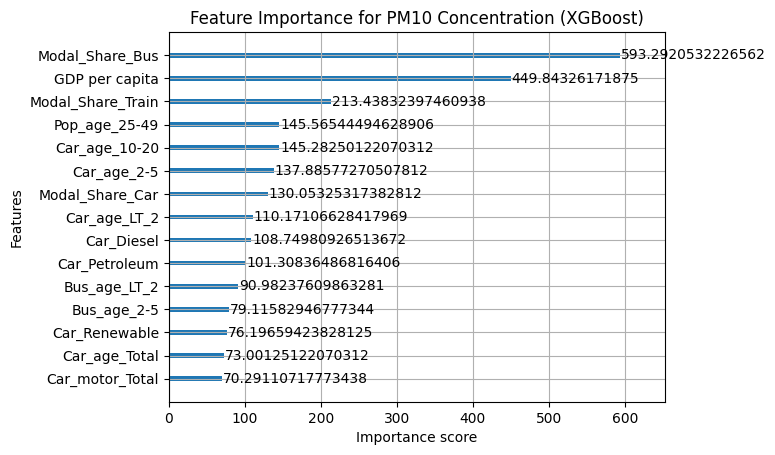

In [21]:
plt.figure(figsize=(10, 8))
xgb.plot_importance(xgb_reg_pm10, importance_type="gain", max_num_features=15)
plt.title("Feature Importance for PM10 Concentration (XGBoost)")
plt.show()

In [37]:
xgb_reg_pm10_old = xgb.XGBRegressor()
xgb_reg_pm10_old.load_model("Model/xgb_pm10.json")

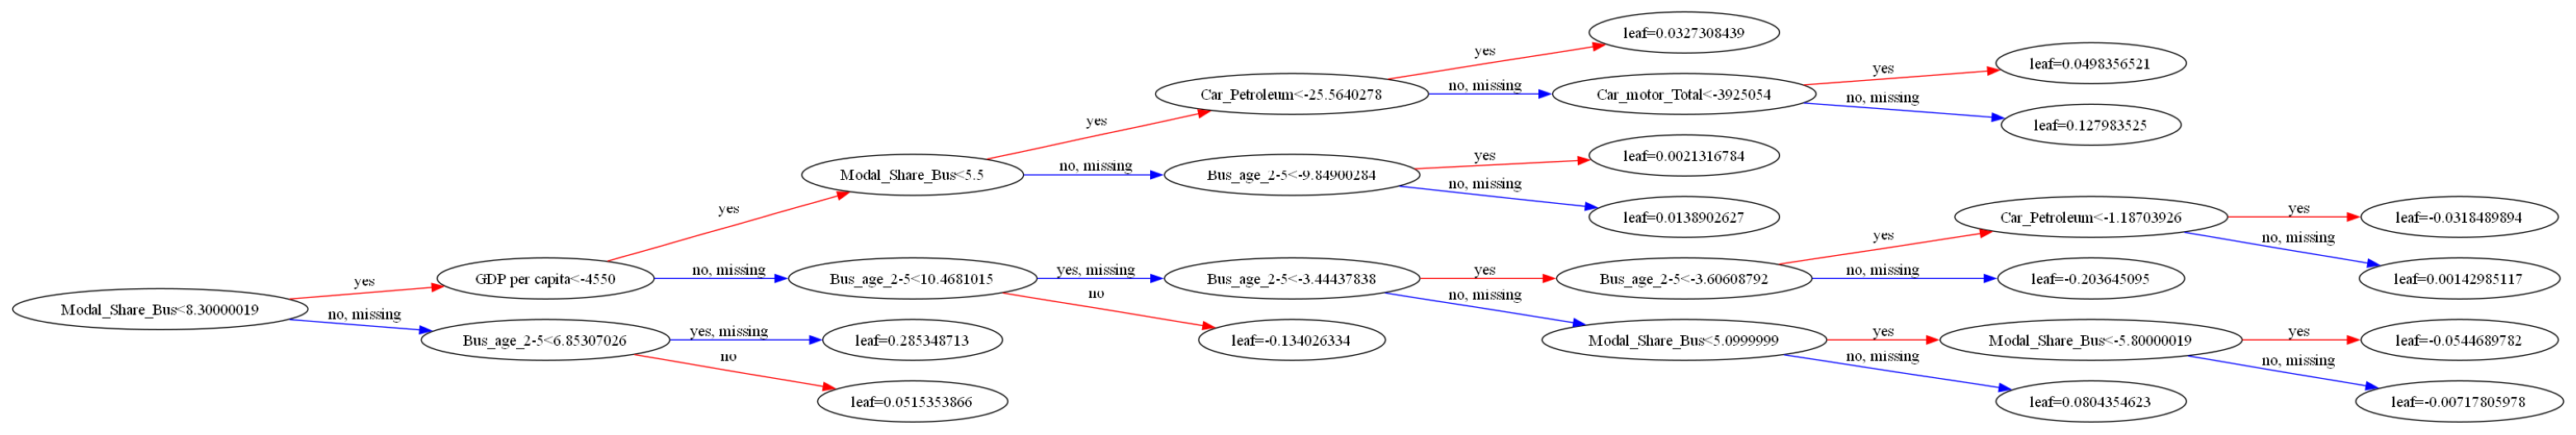

In [39]:
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

# Use XGBoost's matplotlib-based plotting
xgb.plot_tree(xgb_reg_pm10, num_trees=0, rankdir="LR", ax=None)

# Resize figure
plt.gcf().set_size_inches(40, 30)
plt.show()


#### Plot Predicted vs Actual ####

In [27]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors="k")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)  # ideal line
plt.xlabel("Actual PM10 Concentration")
plt.ylabel("Predicted PM10 Concentration")
plt.title("XGBoost Predictions vs Actuals (PM10)")
plt.grid(True)
plt.show()


NameError: name 'y_pred' is not defined

<Figure size 700x700 with 0 Axes>

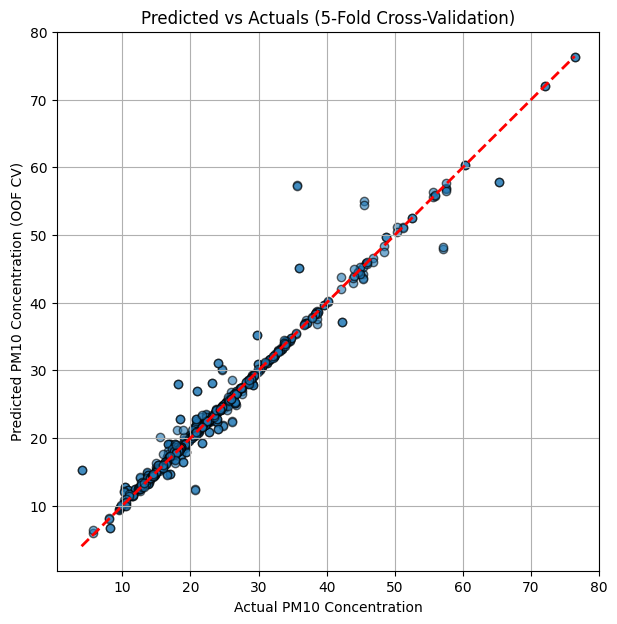

In [45]:
plt.figure(figsize=(7, 7))
plt.scatter(y, oof_preds, alpha=0.6, edgecolors="k")
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", lw=2)
plt.xlabel("Actual PM10 Concentration")
plt.ylabel("Predicted PM10 Concentration (OOF CV)")
plt.title("Predicted vs Actuals (5-Fold Cross-Validation)")
plt.grid(True)
plt.show()

## Prectictions ##

In [ ]:
xgb_reg_pm10 = xgb.XGBRegressor()
xgb_reg_pm10.load_model("Model/xgb_pm10_fine.json")

In [11]:
def predict(model, encoder, input_dict):
    """
    Make a prediction for paarticle concentration from individual input values.
    
    Parameters
    ----------
    model : trained xgb.XGBRegressor
        The fitted XGBoost model.
    encoder : OneHotEncoder
        The fitted encoder for 'Country'.
    input_dict : dict
        A dictionary of input values, e.g.:
        {
            "Country": "Austria",
            "Year": 2015,
            "GDP per capita": 45000,
            "Modal_Share_Car": 75,
            "Modal_Share_Bus": 10,
            ...
        }
    """
    # Convert dict to DataFrame
    X_new = pd.DataFrame([input_dict])
    
    # Drop country and concat
    X_numeric = X_new.copy()
    X_encoded_new = pd.concat([X_numeric.reset_index(drop=True), encoder], axis=1)
    
    # Align columns with training data
    X_encoded_new = encoder.reindex(columns=encoder.columns, fill_value=0)
    
    # Predict
    prediction = model.predict(X_encoded_new)[0]
    return prediction

In [23]:
example_input = {
    "Bus_age_Total": 0,
    "Bus_age_10-20": 0,
    "Bus_age_2-5": 0,
    "Bus_age_5-10": 0,
    "Bus_age_GT_20": 0,
    "Bus_age_LT_2": 0,
    "Bus_Diesel": 0,
    "Bus_Petroleum": 0,
    "Bus_LPG": 0,
    "Bus_Natural_Gas": 0,
    "Bus_Electricity": 0,
    "Car_age_Total": 0,
    "Car_age_10-20": 0,
    "Car_age_2-5": 0,
    "Car_age_5-10": 0,
    "Car_age_GT_20": 0,
    "Car_age_LT_2": 0,
    "Car_Diesel": 0,
    "Car_Petroleum": 0,
    "Car_motor_Total": 0,
    "Car_Renewable": 0,
    "GDP per capita": 0,
    "Population": 0,
    "Population_density": 0,
    "Pop_age_0-14": 0,
    "Pop_age_15-24": 0,
    "Pop_age_25-49": 0,
    "Pop_age_50-64": 0,
    "Pop_age_65-79": 0,
    "Pop_age_GT_80": 0,
    "Modal_Share_Bus": 0,
    "Modal_Share_Car": 0,
    "Modal_Share_Train": 0,
    "Bus_motor_Total": 0
}

prediction = predict(xgb_reg_pm10, data_pm10[0], example_input)
print(f"Predicted delta PM10 Concentration: {prediction:.2f}")

Predicted delta PM10 Concentration: -1.08


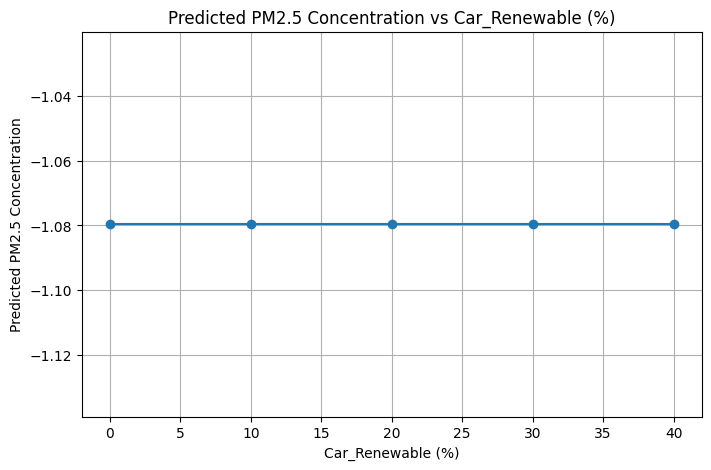

In [ ]:
example_input = {
    "Bus_age_Total": 0,
    "Bus_age_10-20": 0,
    "Bus_age_2-5": 0,
    "Bus_age_5-10": 0,
    "Bus_age_GT_20": 0,
    "Bus_age_LT_2": 0,
    "Bus_Diesel": 0,
    "Bus_Petroleum": 0,
    "Bus_LPG": 0,
    "Bus_Natural_Gas": 0,
    "Bus_Electricity": 0,
    "Car_age_Total": 0,
    "Car_age_10-20": 0,
    "Car_age_2-5": 0,
    "Car_age_5-10": 0,
    "Car_age_GT_20": 0,
    "Car_age_LT_2": 0,
    "Car_Diesel": 0,
    "Car_Petroleum": 0,
    "Car_motor_Total": 0,
    "Car_Renewable": 0,
    "GDP per capita": 0,
    "Population": 0,
    "Population_density": 0,
    "Pop_age_0-14": 0,
    "Pop_age_15-24": 0,
    "Pop_age_25-49": 0,
    "Pop_age_50-64": 0,
    "Pop_age_65-79": 0,
    "Pop_age_GT_80": 0,
    "Modal_Share_Bus": 0,
    "Modal_Share_Car": 0,
    "Modal_Share_Train": 0,
    "Bus_motor_Total": 0
}

car_renewable_values = []
predictions = []
# Car_Renewable = 100% ; 2030 --> X 80% + 3% (2026) / + 5% (2027) / 80% + 10% (2028) / 80% + 15% (2029) / 80% + 20% (2030)
# Car_Petroleum = 0%; 2030 --> X - 3% (2026) / - 5% (2027) / - 10% (2028) / - 15% (2029) / - 20% (2030)
# Car_Diesel = 0%; 2030 --> X - 3% (2026) / - 5% (2027) / - 10% (2028) / - 15% (2029) / - 20% (2030)
Car_Renewable_Sart = 50
Car_Renewable_End = 100 # Intput of the User
dt = Car_Renewable_End - Car_Renewable_Sart
dt_year = 2030 - 2025
steppsize = int((Car_Renewable_End - Car_Renewable_Sart)/(dt_year))
for value in range(0, dt, steppsize):
    example_input["Car_Renewable"] = value #
    example_input["Car_Diesel"] = -value / 2
    example_input["Car_Petroleum"] = -value / 2
    prediction = predict(xgb_reg_pm10, data_pm10[0], example_input)
    car_renewable_values.append(value)
    predictions.append(prediction)

plt.figure(figsize=(8, 5))
plt.plot(car_renewable_values, predictions, marker='o')
plt.xlabel("Car_Renewable (%)")
plt.ylabel("Predicted PM2.5 Concentration")
plt.title("Predicted PM2.5 Concentration vs Car_Renewable (%)")
plt.grid(True)
plt.show()
